# Introduction to Machine Learning -- MC886
# Assignment 2 - Model Selection and Regularization

**Professor:** Marcelo da Silva Reis  
**PED:** Daniel Gardin Gratti  
**PAD:** Guilherme Henrique Ichiro Seto Ito

---

## Objective

This assignment investigates the effects of overfitting in different data regimes
and test conditions.
The goal is to understand the different results of regularization when data
availability changes, and how they impact the generalization across two different
distributions.

### Guidelines

> Please read these guidelines carefully.

1. Questions can be answered in English or in Portuguese.

2. Use data visualization as a primary tool for understanding the problem. Inspect the training data, corrupted inputs, and model behavior. When an assumption is uncertain, verify it empirically through plots.

3. The provided code serves only as a reference. Modifications are allowed, including changes to functions and the introduction of new components. Code clarity and organization are required.

4. The use of generative AI tools (e.g., ChatGPT, GitHub Copilot, DeepSeek, LLaMA) is permitted strictly for implementation support. The use of AI for interpreting, analyzing, or discussing experimental results is discouraged. Submissions must include:
   - A declaration of which models were used.
   - The prompts that generated any incorporated code.

5. Do not hesitate to reach out to the PED/PAD via Discord.

### About the Dataset

This assignment uses the [MNIST](https://web.archive.org/web/20240213122836/http://yann.lecun.com/exdb/mnist/) dataset, a standard benchmark for image classification. It consists of 28×28 grayscale images of handwritten digits (0–9), where each pixel encodes an intensity value in [0, 255].

MNIST is useful here because it is simple enough that a linear model can do well on it, which means the learned weights are directly interpretable as images, where each weight corresponds to the influence of each pixel.

To study robustness and distribution shift, this assignment uses corrupted variants from [MNIST-C](https://github.com/google-research/mnist-c), which applies systematic corruptions to the original images.

The training set consists entirely of corrupted images. The test set contains **two splits**:
- `test_corrupted`: corrupted test images (same distribution as training).
- `test_clean`: the original, uncorrupted MNIST test images.

Performance on `test_corrupted` measures how well the model learned the training task.
Performance on `test_clean` measures how well the model learned digit recognition.

Your job is to train three different models, each one with different number of
available samples:
- Full-data (60000 samples)
- Partial-data (10000 samples)
- Scarce-data (1000 samples)

Finding the best combination of hyper-parameter for each one of them.

In [3]:
from typing import Any

from numpy.typing import NDArray
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
from torch import optim

import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility.
# Do not tune this number
# Re-run the notebook from the beginning before submitting.
seed = 42
torch.random.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [4]:
# The dataset is available in the classroom assignment.
# Ensure you have downloaded it and placed it alongside this notebook.

# DO NOT change this cell

def subsample_dataset(
    X: NDArray[Any], y: NDArray[Any], n: int
) -> tuple[NDArray[Any], NDArray[Any]]:
    n_samples = len(y)

    idxs = np.random.choice(
        n_samples, size=n, replace=False
    )

    return X[idxs], y[idxs]

X_full = np.load("data/train/train_images.npy")
y_full = np.load("data/train/train_labels.npy")

X_partial, y_partial = subsample_dataset(X_full, y_full, 10_000)
X_scarce, y_scarce = subsample_dataset(X_full, y_full, 1_000)

print(f"Full-data set: {X_full.shape[0]} samples")
print(f"Full dataset: {X_full.shape} ")
print(f"Partial-data set: {X_partial.shape[0]} samples")
print(f"Scarce-data set: {X_scarce.shape[0]} samples")

Full-data set: 60000 samples
Full dataset: (60000, 28, 28, 1) 
Partial-data set: 10000 samples
Scarce-data set: 1000 samples


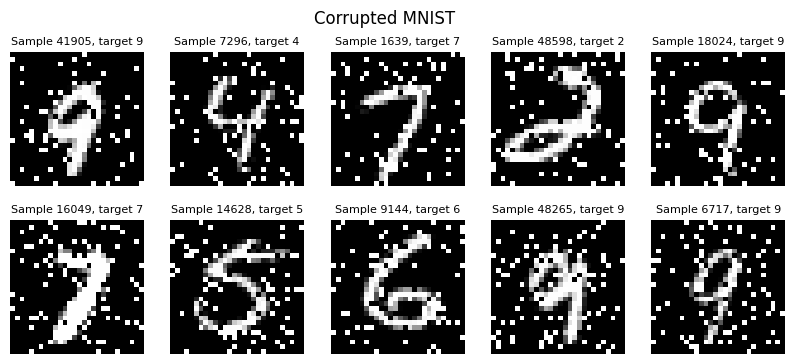

In [5]:
n_cols = 5
n_rows = 2

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2*n_cols, 2*n_rows))

fig.suptitle("Corrupted MNIST")

for i in range(n_rows):
    for j in range(n_cols):
        ax = axs[i, j]
        idx = random.randint(0, len(X_full)-1)

        ax.set_title(f"Sample {idx}, target {y_full[idx]}", fontsize=8)
        ax.imshow(X_full[idx], cmap='grey')
        ax.set_axis_off()

---

## Part 1. Data Analysis and Preprocessing

### 1.1 Exploring the corruption

**(1.0 point)**

Before any modeling, understand what the corruption actually does to the data.

Is the corruption random per-pixel noise, or is it a structured perturbation?
Explore the **training** dataset, understand the distribution and the effects of the introduced
noise.

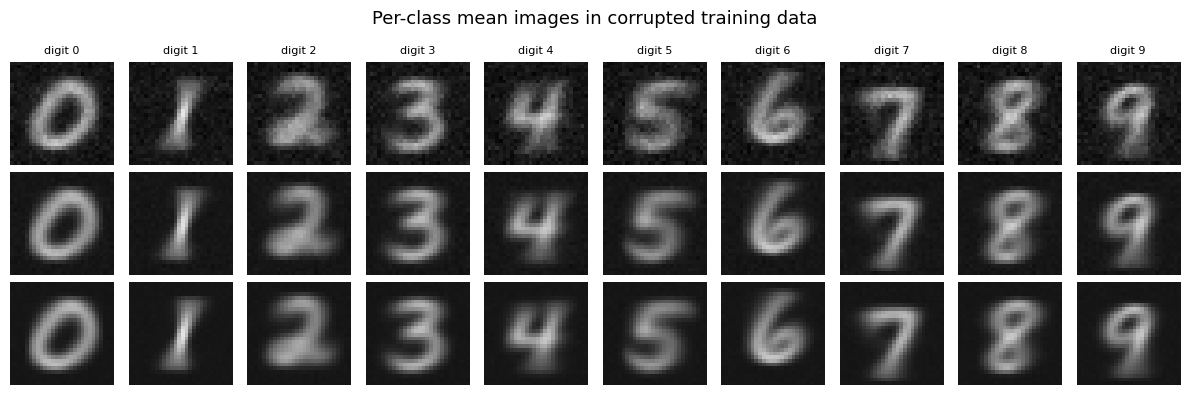

In [6]:
data_regimes = {
    "Scarce": (X_scarce, y_scarce),
    "Partial": (X_partial, y_partial),
    "Full": (X_full, y_full),
}

fig, axs = plt.subplots(len(data_regimes), 10, figsize=(4*len(data_regimes), 4))
for digit in range(10):
    axs[0, digit].set_title(f"digit {digit}", fontsize=8)

for i, name in enumerate(data_regimes):
    X, y = data_regimes[name]


    for digit in range(10):
        mask = (y == digit)
        mean_img = X[mask].mean(axis=0)
        axs[i, digit].imshow(mean_img, cmap="gray", vmin=0, vmax=255)
        axs[i, digit].axis("off")

    axs[i, 0].set_ylabel(f"{name}-data regime", fontsize=9)

plt.suptitle("Per-class mean images in corrupted training data", fontsize=13)
plt.tight_layout()
plt.show()

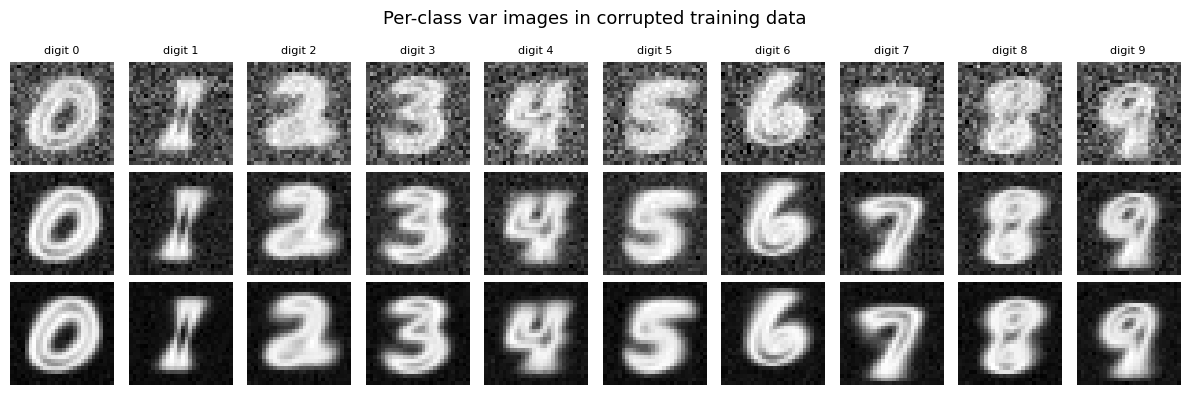

In [7]:
fig, axs = plt.subplots(len(data_regimes), 10, figsize=(4*len(data_regimes), 4))
for digit in range(10):
    axs[0, digit].set_title(f"digit {digit}", fontsize=8)

for i, name in enumerate(data_regimes):
    X, y = data_regimes[name]


    for digit in range(10):
        mask = (y == digit)
        var_img = X[mask].var(axis=0)
        axs[i, digit].imshow(var_img, cmap="gray")
        axs[i, digit].axis("off")

    axs[i, 0].set_ylabel(f"{name}-data regime", fontsize=9)

plt.suptitle("Per-class var images in corrupted training data", fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# Implement other visualizations to understand the corruption. 

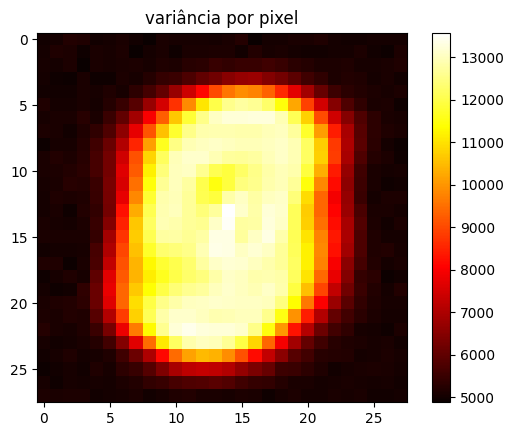

In [9]:
# aq ver a variancia por pixel 

var_img = X_full.var(axis=0)

plt.imshow(var_img, cmap="hot")
plt.title("variância por pixel")
plt.colorbar()
plt.show()

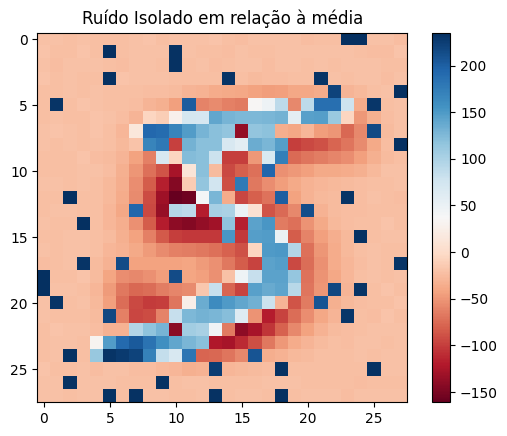

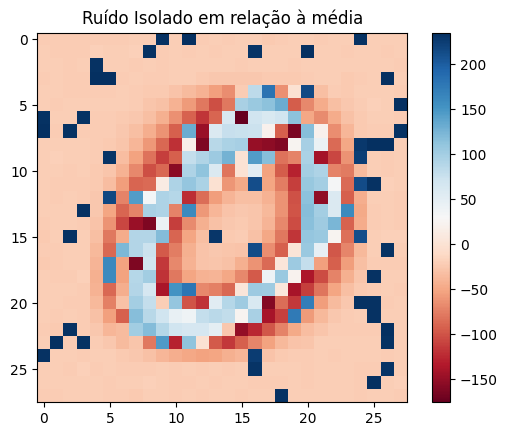

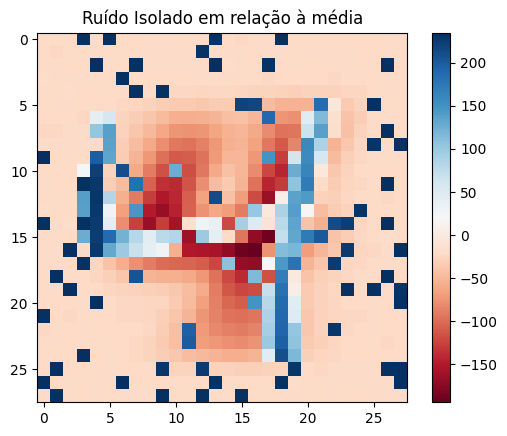

In [10]:


for i in range(3):
    digit = y_full[i]
    mask = (y_full == digit)
    # mask = y_full

    mean_digit = X_full[mask].mean(axis=0)

    noise_isolated = X_full[i] - mean_digit

    plt.imshow(noise_isolated, cmap='RdBu')
    plt.title("Ruído Isolado em relação à média")
    plt.colorbar()
    plt.show()

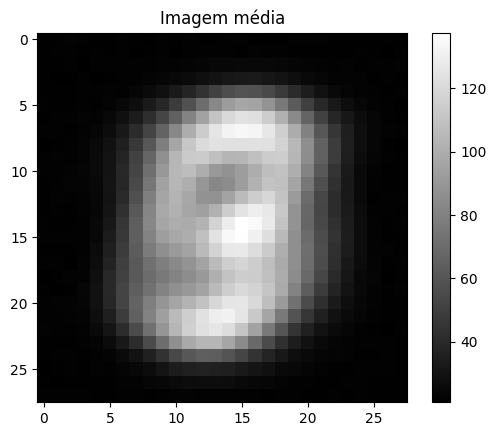

In [11]:
media_geral = X_full.mean(axis=0)

plt.imshow(media_geral, cmap="gray")
plt.title("Imagem média")
plt.colorbar()
plt.show()

> **Question 1.1**
>
> Describe the corruption. Is it random and per-sample, or is it systematic and shared across images? Does it vary across digit classes?
>
> Are there data regimes where the corruption can effect more than in others?
> Hypothesize how these different regimes will affect a model trained on them.

A corrupção observada no dataset é aleatória e por amostra, operando de forma independente para cada amostra. Isso significa que o resultado da corrupção em cada imagem é distinto do outro, sem um padrão fixo em comum, onde a alteração dos pixels ocorre de forma imprevisível. Essa aleatoriedade é evidenciada pela análise da variância nas bordas das imagens, em que em um cenário de corrupção estruturada ou inexistente, essas regiões de fundo permaneceriam com variância nula, porém, o heatmap revela uma variabilidade constante e espalhada. Com isso, confirma-se que os pixels de fundo são alterados de forma independente em cada exemplo, como pode ser observado ao analisar o ruído isolado em 3 das imagens, em que fica nítido uma certa esparsidade e aleatoriedade nas coordenadas dos pixels e na intensidade aplicada sobre eles. Além disso, a aparência com um efeito de blur observada na média global não se dá por uma transformação fixa inserida nas imagens, mas sim pela média desse ruído aleatório. Ao sobrepor muitas imagens ruidosas, os componentes aleatórios tendem a se distribuir uniformemente. Por fim, dada tal aleatoriedade, essa corrupção é independente da classe do dígito, ou seja, a corrupção é uma camada de interferência que ignora o dígito original da imagem.
A eficácia de um modelo treinado sob essas condições depende do regime dos dados. No caso de regime Scarce-data, isto é, dados escassos, o modelo linear torna-se altamente vulnerável ao ruído, com maior risco de interpretar pixels aleatórios de fundo como características relevantes para a classificação, o que leva ao overfitting de artefatos inúteis. Já o regime Full-data, com dados completos, há uma menor sensibilidades às variações e possíveis outliers e ruídos. Com um volume maior de dados, o modelo consegue atingir uma melhor generalização e aprendizado dos padrões importantes dos dados, resultando em um modelo mais robusto e capaz de generalizar para dados não vistos ainda. Em suma, a corrupção pode afetar mais um modelo no regime Scarce-data, em que o modelo se torna sensível demais às alterações provocadas por essa interferência.

### 1.2 Preprocessing

**(1.0 point)**

Before training, the raw data must be brought into a form suitable for gradient-based optimization.

Two considerations are important here:

1. **Scale.** Raw pixel values are in [0, 255]. Gradient descent is sensitive to the scale of inputs; large input values produce large gradients, which can destabilize training.

2. **Data leakage.** Any statistics used for preprocessing must be computed from the training set only, then applied to all other splits.
Computing statistics on the full dataset, including test data, leaks information about the test distribution into preprocessing and invalidates evaluation.

In [12]:
# Implement the preprocessing on all data-regimes. You can use scikit-learn, or other libraries.

#lidar c sensibilidade à escala - normalizar
def preprocess_data(X: np.ndarray, infos_regime: tuple, is_fit: bool) -> tuple[np.ndarray, tuple]:
    X_2d = X.reshape(X.shape[0], -1).astype(np.float32)
    X_scaled = X_2d / 255.0
    
    if is_fit:
        mean = X_scaled.mean(axis=0)
        std = X_scaled.std(axis=0)
    else:
        mean, std = infos_regime
        
    X_final = (X_scaled - mean) / std
    
    return X_final, (mean, std)

In [13]:
X_train_full, infos_full = preprocess_data(X_full, infos_regime=None, is_fit=True)
X_train_partial, infos_partial = preprocess_data(X_partial, infos_regime=None, is_fit=True)
X_train_scarce, infos_scarce = preprocess_data(X_scarce, infos_regime=None, is_fit=True)


> **Question 1.2**
>
> Describe the preprocessing choices made above. What strategy have you chosen, and why?

A Regressão Logística Multinomial espera, para um dataset com N amostras, imagens 28x28 = 784 pixels e 1 canal de cor, uma matriz (N, 784). Então, a primeira etapa do pré-processamento é realizar a conversão de (N, 28, 28, 1) para (N, 784), a partir do achatamento: 28x28x1 = 784. 
Além disso, uma vez que o gradiente descendente é extremamente sensível à escala dos inputs, precisamos normalizar os valores dos pixels, que originalmente estão na escala [0, 255], e normalizamos para estarem na escala [0,1]. Isso evita instabilidades e erros no treinamento e facilita a convergência.
Por fim, aplicamos a padronização, para ajustar as distribuições estatísticas de cada pixel. Isso é importante para nivelar a importância das características, garantindo que o modelo não atribua relevância indevida a pixels apenas pela sua intensidade alta ou variabilidade, mas pelo seu comportamento em relação ao conjunto dos dados. Assim, evita-se que pixels de intensidades menores, e que variem menos entre as imagens, sejam erroneamente ignorados pelo modelo.

---

## Part 2. Multinomial Logistic Regression

### 2.1 The model

Multinomial logistic regression (also called softmax regression) is the natural extension of binary logistic regression to $K > 2$ classes.

Given an input $\mathbf{x} \in \mathbb{R}^d$, the model computes a score (logit) for each class $k$:

$$z_k = \mathbf{w}_k^\top \mathbf{x} + b_k$$

Each logit is an unconstrained real number, in order to transform these values into
probabilities, where $p_k \geq 0$ and $\sum_k p_k = 1$, the softmax function
is used:

$$P(y = k \mid \mathbf{x}) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Training minimizes the **cross-entropy loss**, which is the negative log-likelihood of the true class under this distribution:

$$\mathcal{L}(\mathbf{W}, \mathbf{b}) = -\frac{1}{N} \sum_{i=1}^{N} \log P(y_i \mid \mathbf{x}_i)$$

For MNIST with $d = 784$ pixels and $K = 10$ classes, the weight matrix $\mathbf{W} \in \mathbb{R}^{10 \times 784}$ has one row per class. Each row $\mathbf{w}_k$ can be reshaped into a 28×28 image and visualized directly: positive values indicate pixels whose brightness increases the log-odds of class $k$, whereas negative values suppress it.
This direct interpretability is one reason we use a linear model here.

### 2.2 Regularization

Standard cross-entropy minimization has no preference over the parameter space.
With enough capacity, or with corrupted data that contains spurious features, the model can assign large weights to uninformative or noisy pixels if doing so reduces training loss.

Regularization considers an additional assumption over the nature of the learned weights,
adding a penalty on the weights to the loss:

$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \lambda \cdot \Omega(\mathbf{W})$$

Two common choices for $\Omega$:

- **L2 (Ridge):** $\Omega(\mathbf{W}) = \|\mathbf{W}\|_2^2 = \sum_{k,j} w_{kj}^2$. Penalizes large weights uniformly, where all weights shrink toward zero but none are forced exactly to zero.
In PyTorch's optimizers, L2 is implemented as `weight_decay`.

- **L1 (Lasso):** $\Omega(\mathbf{W}) = \|\mathbf{W}\|_1 = \sum_{k,j} |w_{kj}|$. Penalizes the sum of absolute values, producing sparse solutions where many weights are driven to exactly zero.

The hyperparameter $\lambda \geq 0$ controls the strength of regularization.
$\lambda = 0$ recovers the unregularized problem.

**(2.0 point)**

Implement the Multinomial Logistic Regression model using PyTorch's nn.Module
for the linear model (image as input and logits as outputs), and SGD with both
L1 and L2 regularization methods.

In [14]:
# Implementation goes here

class LinearModel(nn.Module):
    def __init__(self, n_features: int, n_classes: int):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(n_features, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.linear(x) 
        return out

def accuracy(logits: torch.Tensor, y: torch.Tensor) -> float:
    """Fraction of correctly predicted samples."""
    y_pred = logits.argmax(dim=-1)
    return (y == y_pred).float().mean().item()


def train(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    n_iter: int,
    lr: float = 0.1,
    l1: float = 0.0,
    l2: float = 0.0
) -> list[float]:
    """
    Train a model using full-batch SGD with L1/L2 regularization.

    Returns the list of per-iteration training losses.
    """
    losses = []
    criterion = nn.CrossEntropyLoss()                        
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=l2)   
    for epoch in range(n_iter):
        optimizer.zero_grad() # limpa os gradientes acumulados

        # forward 
        logits = model.forward(X) # calcula logits (modelo faz a predição)

        loss = criterion(logits, y) 
        accuracy_score = accuracy(logits, y)

        # lasso
        if l1 > 0:
            l1_loss = sum(p.abs().sum() for p in model.parameters())
            loss += l1 * l1_loss

        # backward e otimizar
        loss.backward()       # calcula o gradiente
        optimizer.step()      # atualiza os pesos

        # print progress every 100 epochs
        losses.append(loss.item())
        if (epoch+1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{n_iter}]\tLoss: {loss.item():.4f}\tAccuracy: {accuracy_score:.4f}")

    return losses

### 2.3 Baseline mode

**(2.0 points)**

Train a unregularized model on each training set and observe the training loss
per iteration on each model during training.

To diagnose and understand what the trained model have learned, we visualize the
learned weights as a heatmap.

In [15]:
print(X_scarce.shape, y_scarce.shape)

(1000, 28, 28, 1) (1000,)


In [16]:
model = LinearModel(n_features=28*28, n_classes=10)

X_train_scarce = torch.from_numpy(X_train_scarce).float()
y_scarce = torch.from_numpy(y_scarce).long()

X_train_partial = torch.from_numpy(X_train_partial).float()
y_partial = torch.from_numpy(y_partial).long()

X_train_full = torch.from_numpy(X_train_full).float()
y_full = torch.from_numpy(y_full).long()

In [17]:
model_scarce = LinearModel(n_features=28*28, n_classes=10)
losses_scarce = train(model_scarce, X_train_scarce, y_scarce, n_iter=1000, lr=0.01)

print("Scarce-data regime training complete.")
print()
model_partial = LinearModel(n_features=28*28, n_classes=10)
losses_partial = train(model_partial, X_train_partial, y_partial, n_iter=1000, lr=0.01)
print("Partial-data regime training complete.")
print()
model_full = LinearModel(n_features=28*28, n_classes=10)
losses_full = train(model_full, X_train_full, y_full, n_iter=1000, lr=0.01)

Epoch [100/1000]	Loss: 0.7286	Accuracy: 0.8610
Epoch [200/1000]	Loss: 0.4340	Accuracy: 0.9450
Epoch [300/1000]	Loss: 0.3048	Accuracy: 0.9720
Epoch [400/1000]	Loss: 0.2310	Accuracy: 0.9860
Epoch [500/1000]	Loss: 0.1836	Accuracy: 0.9930
Epoch [600/1000]	Loss: 0.1510	Accuracy: 0.9960
Epoch [700/1000]	Loss: 0.1276	Accuracy: 0.9970
Epoch [800/1000]	Loss: 0.1100	Accuracy: 1.0000
Epoch [900/1000]	Loss: 0.0965	Accuracy: 1.0000
Epoch [1000/1000]	Loss: 0.0859	Accuracy: 1.0000
Scarce-data regime training complete.

Epoch [100/1000]	Loss: 0.9563	Accuracy: 0.7483
Epoch [200/1000]	Loss: 0.7045	Accuracy: 0.8157
Epoch [300/1000]	Loss: 0.5981	Accuracy: 0.8413
Epoch [400/1000]	Loss: 0.5363	Accuracy: 0.8553
Epoch [500/1000]	Loss: 0.4945	Accuracy: 0.8663
Epoch [600/1000]	Loss: 0.4635	Accuracy: 0.8744
Epoch [700/1000]	Loss: 0.4392	Accuracy: 0.8813
Epoch [800/1000]	Loss: 0.4193	Accuracy: 0.8871
Epoch [900/1000]	Loss: 0.4026	Accuracy: 0.8914
Epoch [1000/1000]	Loss: 0.3883	Accuracy: 0.8953
Partial-data regime

In [18]:
# Visualize learned weight images, one per digit class.
# Use a diverging colormap: red = positive weight (pixel increases log-odds),
# blue = negative weight (pixel suppresses log-odds).

def plot_weights(weights: NDArray[np.float32], title: str) -> None:
    fig, axs = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(title, fontsize=13)

    for digit in range(10):
        ax = axs[digit // 5, digit % 5]
        ax.imshow(weights[digit].reshape(28, 28), cmap="icefire")
        ax.set_title(f"digit {digit}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [19]:
modelos = {
    "Scarce": model_scarce,
    "Partial": model_partial,
    "Full": model_full,
}
for nome, modelo in modelos.items():
    w = modelo.linear.weight.detach().numpy()
    sparsity = (np.abs(w) < 1e-4).mean() 
    print(f"Sparsity of the learned weights for model {nome}: {sparsity:.4f}")



Sparsity of the learned weights for model Scarce: 0.0024
Sparsity of the learned weights for model Partial: 0.0027
Sparsity of the learned weights for model Full: 0.0023


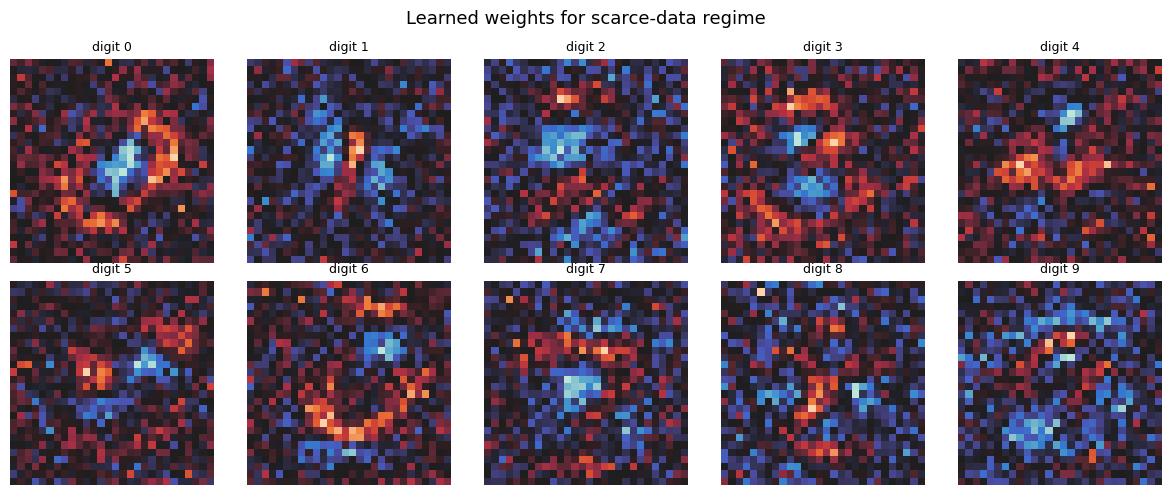

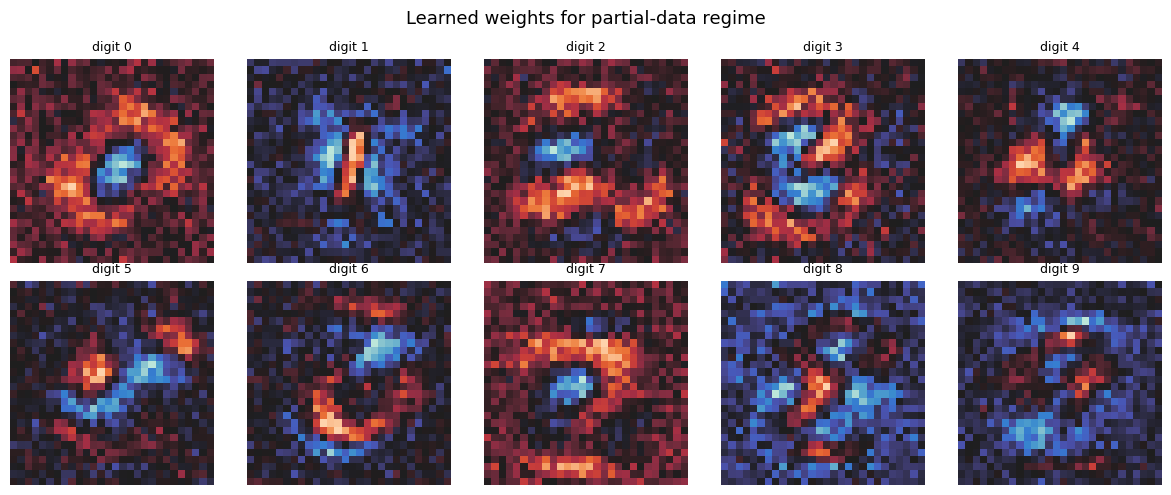

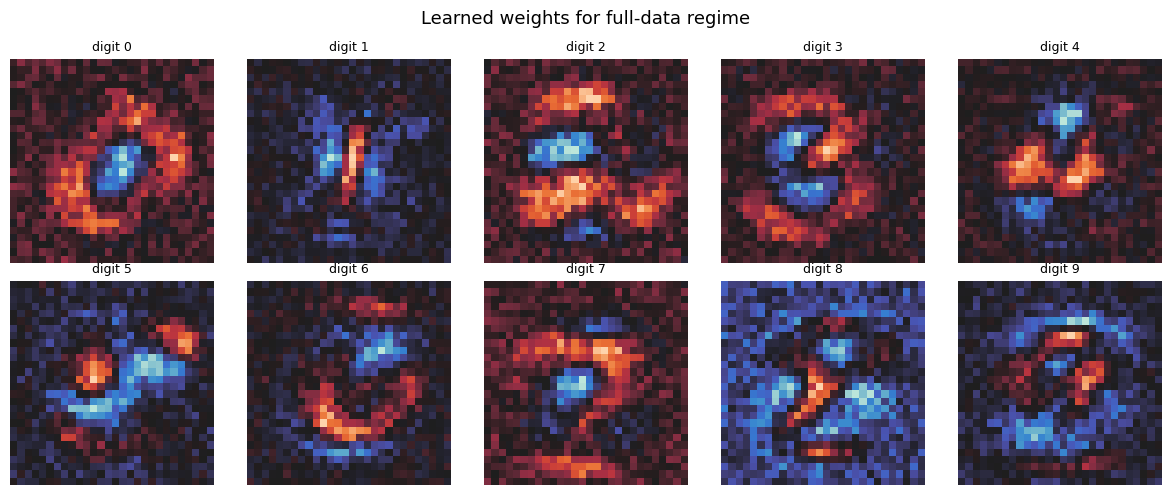

In [20]:
plot_weights(model_scarce.linear.weight.detach().numpy(), title="Learned weights for scarce-data regime")
plot_weights(model_partial.linear.weight.detach().numpy(), title="Learned weights for partial-data regime")
plot_weights(model_full.linear.weight.detach().numpy(), title="Learned weights for full-data regime")



In [45]:
target_lambda = 1.0

print("Regime | L1 Accuracy | L2 Accuracy")

for regime in ["Scarce", "Partial", "Full"]:
    l1_val = results[regime]["L1"][target_lambda]
    l2_val = results[regime]["L2"][target_lambda]
    print(f"{regime} | {l1_val} | {l2_val:}")

Regime | L1 Accuracy | L2 Accuracy
Scarce | 0.16999999880790712 | 0.7829999923706055
Partial | 0.16389999985694886 | 0.808400011062622
Full | 0.13804999887943267 | 0.8103666543960572


> **Question 2.3**
>
> Inspect the weight images for each baseline model. How do you explain the
> weight values in the heatmap, and what patterns do they show?
>
> Compare between the model, how are they different?

Os valores dos pesos em cada mapa de calor refletem a importância de cada pixel para identificar cada dígito. Em geral, os pixels mais relevantes para a classificação de um dígito específico terão pesos mais altos (vermelhos), indicando que o modelo atribui maior importância a esses pixels para distinguir aquela classe.

Podemos notar alguns padrões, em que os pesos mais altos tendem a ficar localizados em regiões específicas da imagem, onde os dígitos geralmente aparecem. Por exemplo, para o dígito 0, os pesos mais altos estão localizados ao redor da borda circular, já para o dígito 1, eles estão concentrados em uma linha vertical. Notamos, entretanto, que os pesos mais altos não estão somente localizados nessas regiões, mas também aparecem em outras áreas da imagem, o que pode indicar que o modelo está capturando ruídos presentes nos dados. 

Comparando os modelos treinados, observa-se que o modelo treinado com o conjunto completo de dados (full-data) tende a apresentar pesos mais focados e consistentes nas regiões relevantes para cada dígito. O modelo treinado usando o conjunto parcial de dados (partial-data) também demonstra certa concentração de pesos nas regiões relevantes, mas com uma maior dispersão e menos consistência, o que pode ser um indicativo de que o modelo teve mais dificuldade em aprender os padrões importante devido à menor quantidade de dados. Por fim, o modelo treinado com o conjunto escasso de dados (scarce-data) apresenta uma distribuição de pesos mais dispersa e menos interpretável, sugerindo que o modelo está capturando muitos ruídos, podendo ser um indicativo de overfitting.

---

## Part 3. Regularization

**(2.0 points)**

We now introduce regularization and sweep over $\lambda$ values for both L1 and L2 penalties.

Your **only decision criterion** in this part is cross-validation accuracy computed on the corrupted training data, exactly what you would have in a real scenario without access to an unlabeled clean test set.

For each configuration (data regime x reg type x $\lambda$), use K-fold cross-validation to estimate validation accuracy.
Then, for each regularizer, **select the best $\lambda$** by CV and train a final model on the full training set.
Store the final models, they will be evaluated after model selection is complete.

> **Decision task** Report, per regularizer and data regimes, which $\lambda$ you selected and why.
Inspect the weight images of your chosen models and describe what you observe.


In [21]:
from sklearn.model_selection import KFold

#parametros
lambdas = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
n_splits = 5
n_iter = 1000
lr = 0.01

data_regimes = {
    "Scarce": (X_train_scarce, y_scarce),
    "Partial": (X_train_partial, y_partial),
    "Full": (X_train_full, y_full),
}

results = {}
for regime in data_regimes:
    results[regime] = {"L1": {}, "L2": {}}


for regime_name, (X_regime, y_regime) in data_regimes.items():
    X_np = X_regime.numpy() 
    y_np = y_regime.numpy()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for reg_type in ["L1", "L2"]:
        for lam in lambdas:
            fold_accuracies = []

            for fold, (train_idx, val_idx) in enumerate(kf.split(X_np)):
                X_fold_train, X_fold_val = X_np[train_idx], X_np[val_idx]
                y_fold_train, y_fold_val = y_np[train_idx], y_np[val_idx]

                mean = X_fold_train.mean(axis=0)
                std = np.maximum(X_fold_train.std(axis=0), 1e-8)
                X_fold_train = (X_fold_train - mean) / std
                X_fold_val = (X_fold_val - mean) / std

                X_tensor = torch.tensor(X_fold_train, dtype=torch.float32)
                y_tensor = torch.tensor(y_fold_train, dtype=torch.long)
                X_val = torch.tensor(X_fold_val, dtype=torch.float32)
                y_val = torch.tensor(y_fold_val, dtype=torch.long)

                
                model = LinearModel(n_features=28*28, n_classes=10)
                if reg_type == "L1":
                    l1 = lam
                    l2 = 0.0
                else:
                    l1 = 0.0
                    l2 = lam

                train(model, X_tensor, y_tensor, n_iter=n_iter, lr=lr, l1=l1, l2=l2)
                

                with torch.no_grad():
                    logits = model(X_val)
                    acc = accuracy(logits, y_val)
                fold_accuracies.append(acc)

            mean_accuracy = np.mean(fold_accuracies)
            results[regime_name][reg_type][lam] = mean_accuracy
            print(f"{reg_type}: λ={lam:.4f}: CV accuracy = {mean_accuracy:.4f}")

Epoch [100/1000]	Loss: 0.6937	Accuracy: 0.8825
Epoch [200/1000]	Loss: 0.3945	Accuracy: 0.9638
Epoch [300/1000]	Loss: 0.2679	Accuracy: 0.9850
Epoch [400/1000]	Loss: 0.1983	Accuracy: 0.9937
Epoch [500/1000]	Loss: 0.1553	Accuracy: 1.0000
Epoch [600/1000]	Loss: 0.1266	Accuracy: 1.0000
Epoch [700/1000]	Loss: 0.1064	Accuracy: 1.0000
Epoch [800/1000]	Loss: 0.0916	Accuracy: 1.0000
Epoch [900/1000]	Loss: 0.0802	Accuracy: 1.0000
Epoch [1000/1000]	Loss: 0.0713	Accuracy: 1.0000
Epoch [100/1000]	Loss: 0.6866	Accuracy: 0.8813
Epoch [200/1000]	Loss: 0.3905	Accuracy: 0.9513
Epoch [300/1000]	Loss: 0.2644	Accuracy: 0.9862
Epoch [400/1000]	Loss: 0.1952	Accuracy: 0.9937
Epoch [500/1000]	Loss: 0.1525	Accuracy: 1.0000
Epoch [600/1000]	Loss: 0.1242	Accuracy: 1.0000
Epoch [700/1000]	Loss: 0.1044	Accuracy: 1.0000
Epoch [800/1000]	Loss: 0.0898	Accuracy: 1.0000
Epoch [900/1000]	Loss: 0.0786	Accuracy: 1.0000
Epoch [1000/1000]	Loss: 0.0699	Accuracy: 1.0000
Epoch [100/1000]	Loss: 0.6592	Accuracy: 0.9000
Epoch [200/

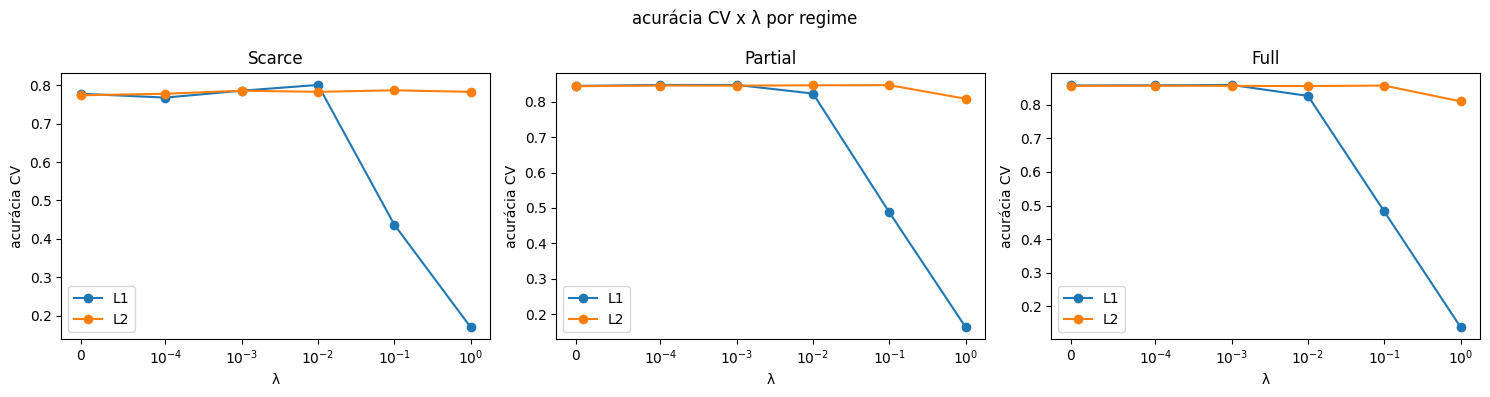

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for i, regime_name in enumerate(["Scarce", "Partial", "Full"]):
    ax = axs[i]
    for reg_type in ["L1", "L2"]:
        accuracies = []
        for lam in lambdas:
            accuracies.append(results[regime_name][reg_type][lam])
        ax.plot(lambdas, accuracies, marker='o', label=reg_type)
    ax.set_xscale('symlog', linthresh=1e-4)
    ax.set_xlabel('λ')
    ax.set_ylabel('acurácia CV')
    ax.set_title(f'{regime_name}')
    ax.legend()

plt.suptitle('acurácia CV x λ por regime')
plt.tight_layout()
plt.show()

In [23]:
best_lambdas = {}
for regime in data_regimes:
    best_lambdas[regime] = {"L1": None, "L2": None} # incializa primeiro sem lambda otimo

for regime_name in data_regimes:
    print(regime_name)
    for reg_type in ["L1", "L2"]:
        best_lam = max(results[regime_name][reg_type], key=results[regime_name][reg_type].get)
        best_lambdas[regime_name][reg_type] = best_lam
        
        print(f"{reg_type}: melhor λ = {best_lam}, accuracia = {results[regime_name][reg_type][best_lam]}")

Scarce
L1: melhor λ = 0.01, accuracia = 0.8009999871253968
L2: melhor λ = 0.1, accuracia = 0.7870000004768372
Partial
L1: melhor λ = 0.001, accuracia = 0.8473000049591064
L2: melhor λ = 0.1, accuracia = 0.8467000007629395
Full
L1: melhor λ = 0.001, accuracia = 0.859250009059906
L2: melhor λ = 0.1, accuracia = 0.8573666691780091


Epoch [100/1000]	Loss: 0.9728	Accuracy: 0.7423
Epoch [200/1000]	Loss: 0.7378	Accuracy: 0.8020
Epoch [300/1000]	Loss: 0.6406	Accuracy: 0.8247
Epoch [400/1000]	Loss: 0.5859	Accuracy: 0.8380
Epoch [500/1000]	Loss: 0.5501	Accuracy: 0.8459
Epoch [600/1000]	Loss: 0.5246	Accuracy: 0.8518
Epoch [700/1000]	Loss: 0.5053	Accuracy: 0.8569
Epoch [800/1000]	Loss: 0.4900	Accuracy: 0.8609
Epoch [900/1000]	Loss: 0.4776	Accuracy: 0.8639
Epoch [1000/1000]	Loss: 0.4672	Accuracy: 0.8666
Epoch [100/1000]	Loss: 0.9791	Accuracy: 0.7373
Epoch [200/1000]	Loss: 0.7407	Accuracy: 0.7990
Epoch [300/1000]	Loss: 0.6425	Accuracy: 0.8225
Epoch [400/1000]	Loss: 0.5873	Accuracy: 0.8360
Epoch [500/1000]	Loss: 0.5511	Accuracy: 0.8449
Epoch [600/1000]	Loss: 0.5252	Accuracy: 0.8508
Epoch [700/1000]	Loss: 0.5056	Accuracy: 0.8552
Epoch [800/1000]	Loss: 0.4902	Accuracy: 0.8588
Epoch [900/1000]	Loss: 0.4776	Accuracy: 0.8620
Epoch [1000/1000]	Loss: 0.4670	Accuracy: 0.8650
Epoch [100/1000]	Loss: 0.9697	Accuracy: 0.7419
Epoch [200/

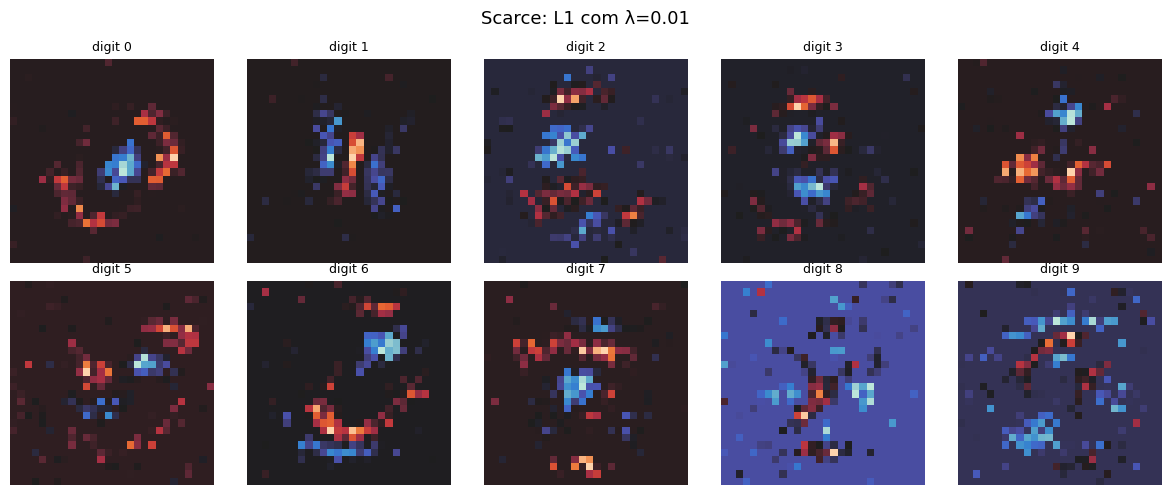

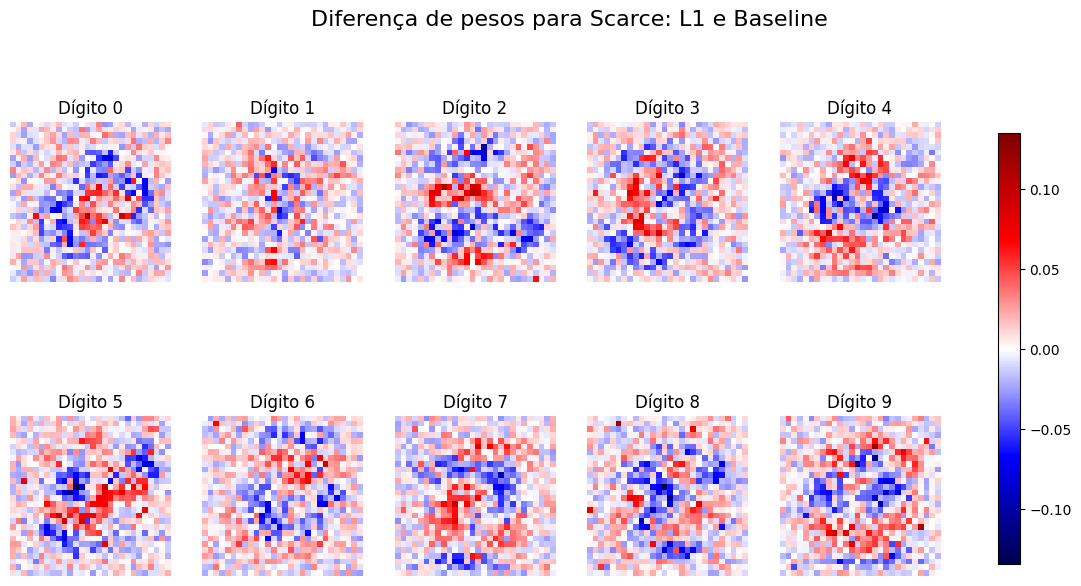

Epoch [100/1000]	Loss: 0.7532	Accuracy: 0.8720
Epoch [200/1000]	Loss: 0.4832	Accuracy: 0.9300
Epoch [300/1000]	Loss: 0.3713	Accuracy: 0.9620
Epoch [400/1000]	Loss: 0.3113	Accuracy: 0.9870
Epoch [500/1000]	Loss: 0.2754	Accuracy: 0.9930
Epoch [600/1000]	Loss: 0.2523	Accuracy: 0.9930
Epoch [700/1000]	Loss: 0.2369	Accuracy: 0.9950
Epoch [800/1000]	Loss: 0.2264	Accuracy: 0.9960
Epoch [900/1000]	Loss: 0.2189	Accuracy: 0.9970
Epoch [1000/1000]	Loss: 0.2136	Accuracy: 0.9990


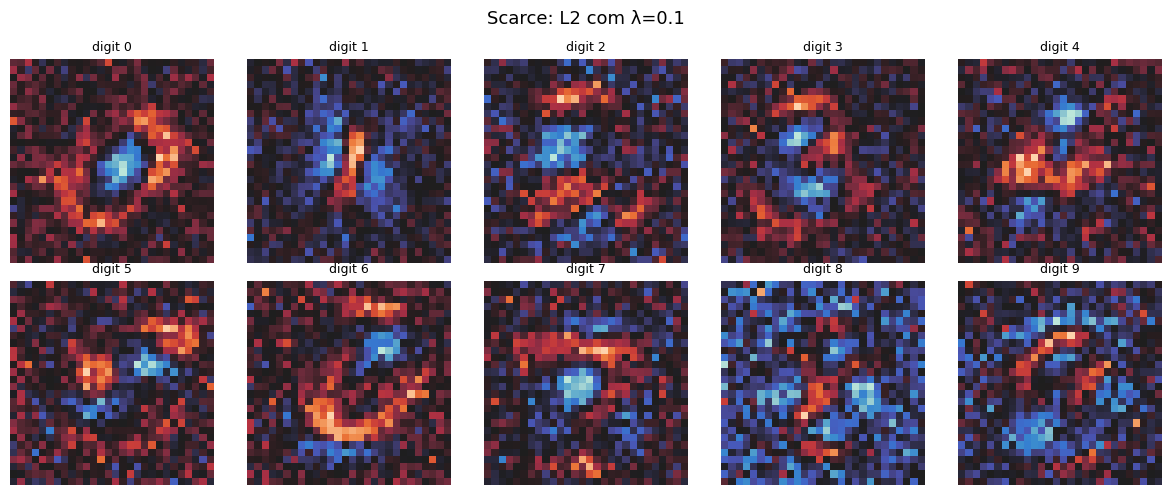

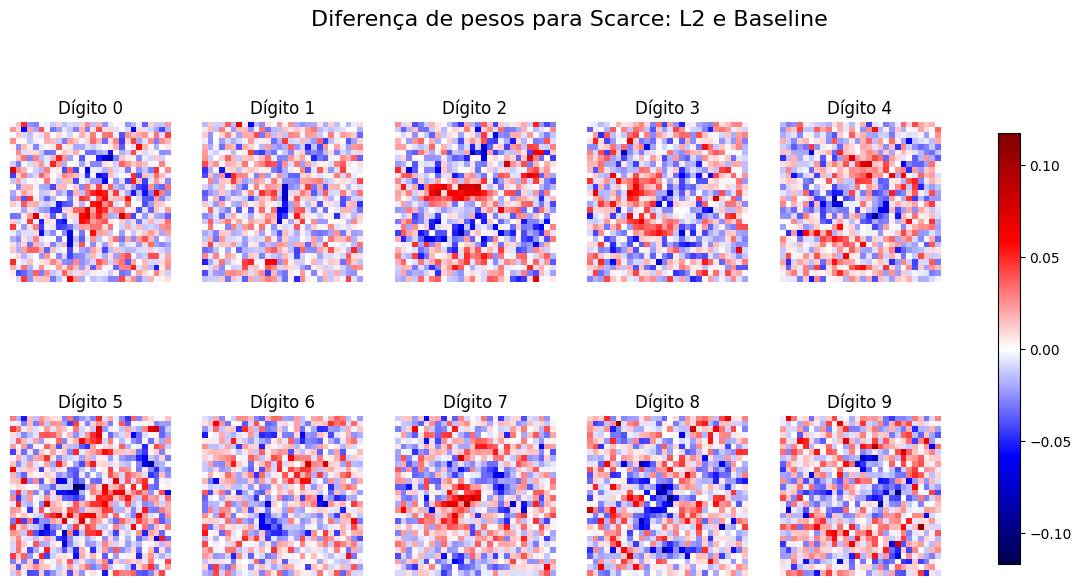

Epoch [100/1000]	Loss: 1.0849	Accuracy: 0.7605
Epoch [200/1000]	Loss: 0.8544	Accuracy: 0.8210
Epoch [300/1000]	Loss: 0.7556	Accuracy: 0.8465
Epoch [400/1000]	Loss: 0.6985	Accuracy: 0.8615
Epoch [500/1000]	Loss: 0.6606	Accuracy: 0.8701
Epoch [600/1000]	Loss: 0.6335	Accuracy: 0.8780
Epoch [700/1000]	Loss: 0.6129	Accuracy: 0.8824
Epoch [800/1000]	Loss: 0.5968	Accuracy: 0.8880
Epoch [900/1000]	Loss: 0.5839	Accuracy: 0.8915
Epoch [1000/1000]	Loss: 0.5733	Accuracy: 0.8945


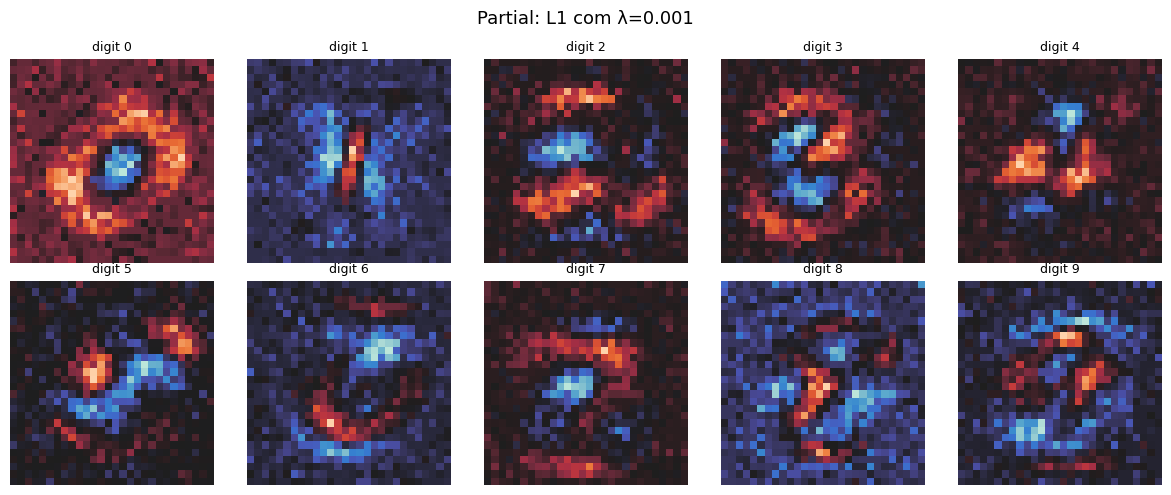

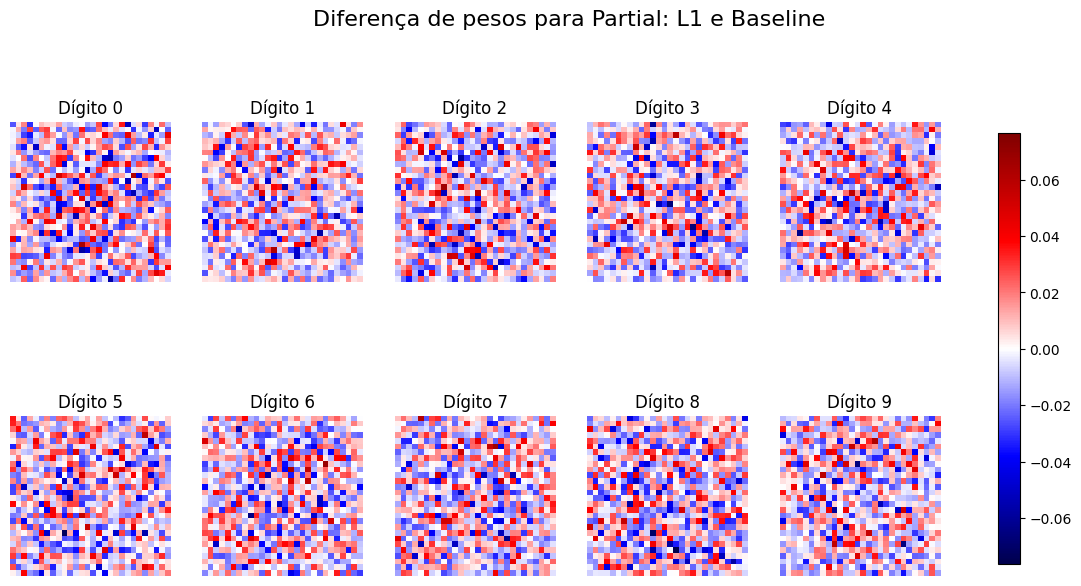

Epoch [100/1000]	Loss: 0.9722	Accuracy: 0.7529
Epoch [200/1000]	Loss: 0.7394	Accuracy: 0.8178
Epoch [300/1000]	Loss: 0.6457	Accuracy: 0.8441
Epoch [400/1000]	Loss: 0.5951	Accuracy: 0.8588
Epoch [500/1000]	Loss: 0.5638	Accuracy: 0.8692
Epoch [600/1000]	Loss: 0.5428	Accuracy: 0.8763
Epoch [700/1000]	Loss: 0.5281	Accuracy: 0.8815
Epoch [800/1000]	Loss: 0.5174	Accuracy: 0.8846
Epoch [900/1000]	Loss: 0.5094	Accuracy: 0.8879
Epoch [1000/1000]	Loss: 0.5032	Accuracy: 0.8900


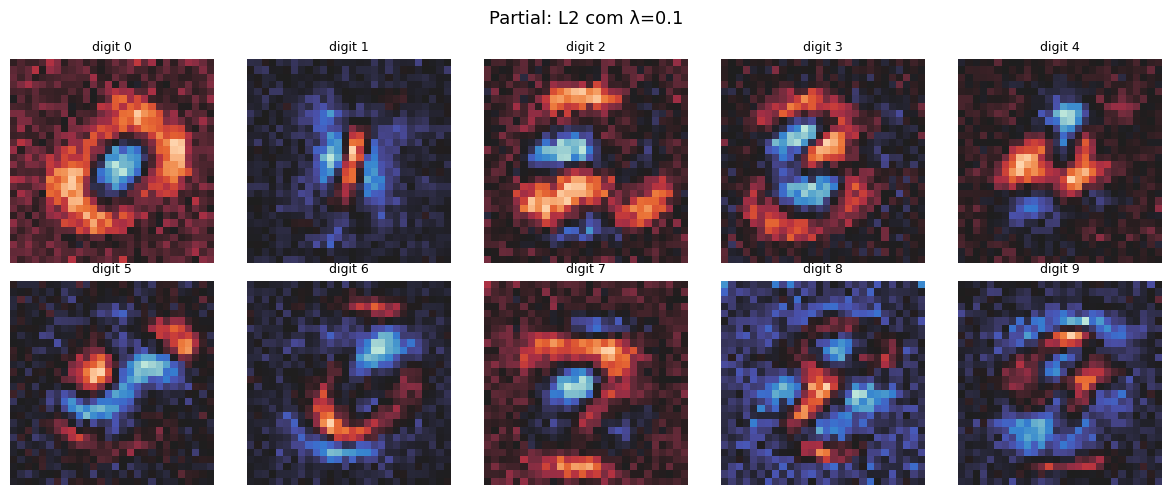

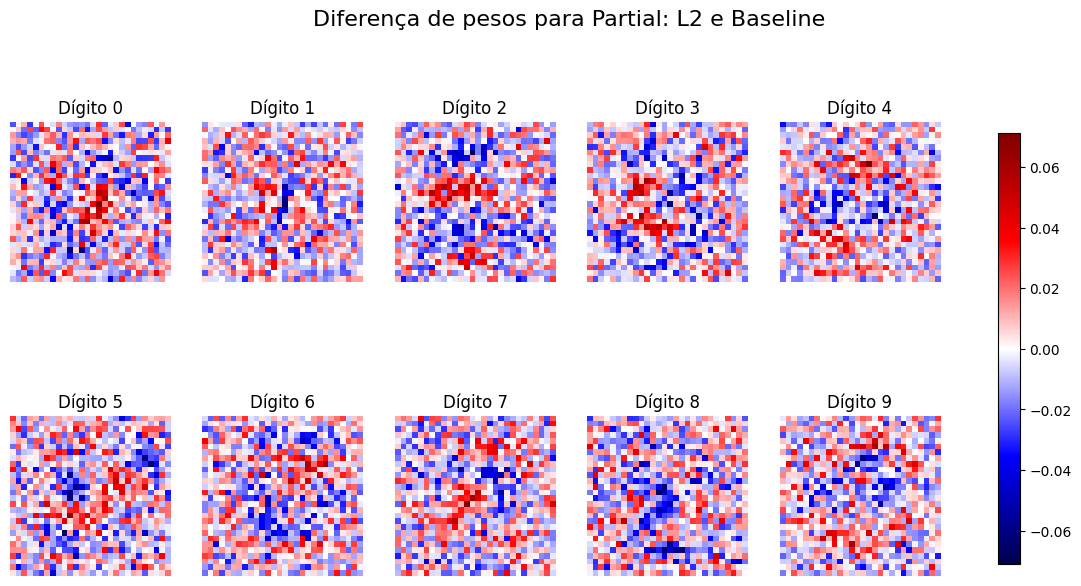

Epoch [100/1000]	Loss: 1.1142	Accuracy: 0.7463
Epoch [200/1000]	Loss: 0.8873	Accuracy: 0.8049
Epoch [300/1000]	Loss: 0.7941	Accuracy: 0.8283
Epoch [400/1000]	Loss: 0.7416	Accuracy: 0.8403
Epoch [500/1000]	Loss: 0.7071	Accuracy: 0.8480
Epoch [600/1000]	Loss: 0.6823	Accuracy: 0.8534
Epoch [700/1000]	Loss: 0.6636	Accuracy: 0.8588
Epoch [800/1000]	Loss: 0.6488	Accuracy: 0.8622
Epoch [900/1000]	Loss: 0.6368	Accuracy: 0.8647
Epoch [1000/1000]	Loss: 0.6269	Accuracy: 0.8669


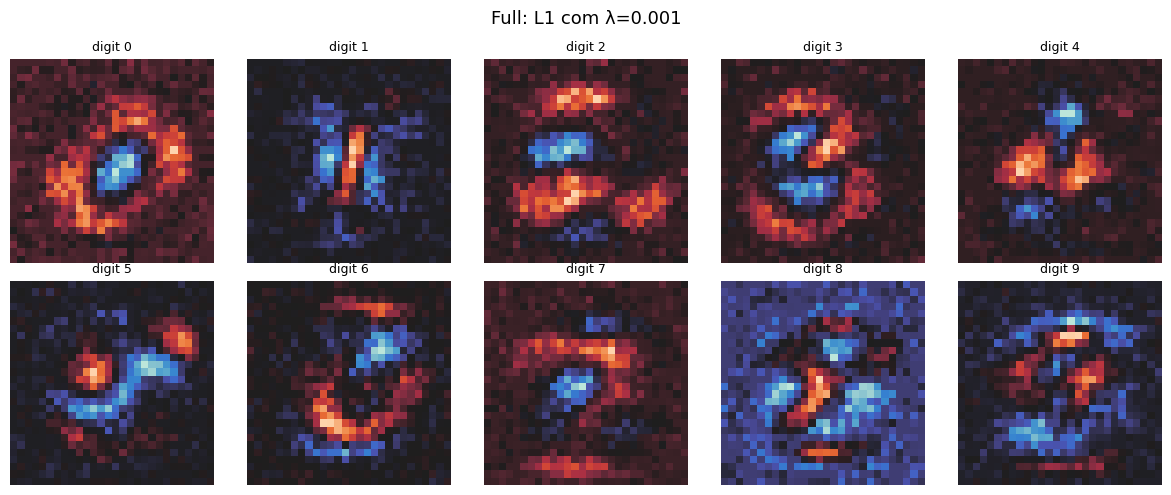

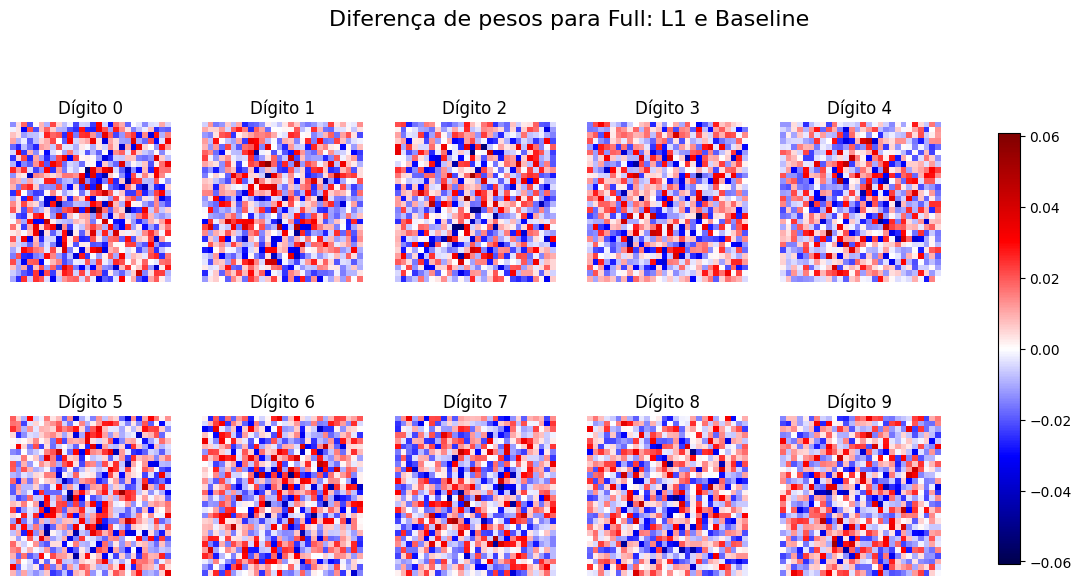

Epoch [100/1000]	Loss: 0.9939	Accuracy: 0.7461
Epoch [200/1000]	Loss: 0.7671	Accuracy: 0.8067
Epoch [300/1000]	Loss: 0.6797	Accuracy: 0.8284
Epoch [400/1000]	Loss: 0.6341	Accuracy: 0.8401
Epoch [500/1000]	Loss: 0.6068	Accuracy: 0.8484
Epoch [600/1000]	Loss: 0.5892	Accuracy: 0.8536
Epoch [700/1000]	Loss: 0.5772	Accuracy: 0.8574
Epoch [800/1000]	Loss: 0.5687	Accuracy: 0.8601
Epoch [900/1000]	Loss: 0.5627	Accuracy: 0.8624
Epoch [1000/1000]	Loss: 0.5582	Accuracy: 0.8640


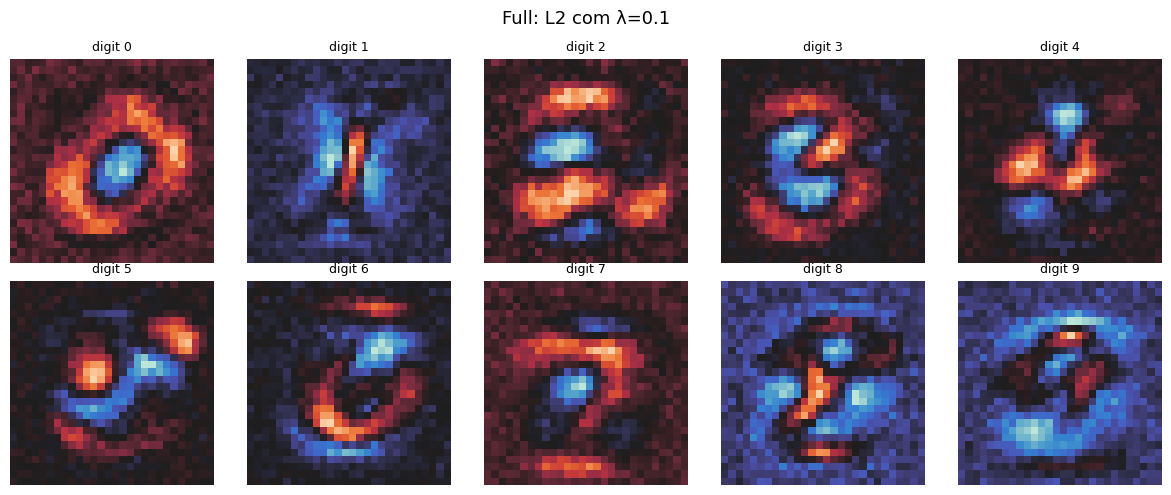

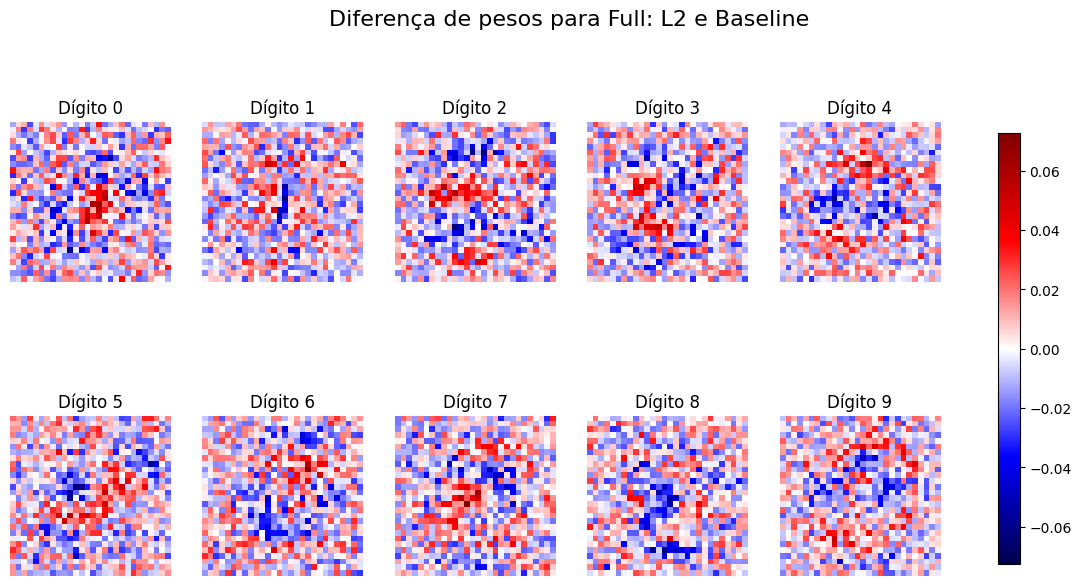

In [24]:
final_models = {}
for regime in data_regimes:
    final_models[regime] = {"L1": None, "L2": None} # incializa primeiro sem lambda otimo
    baseline_model = LinearModel(n_features=28*28, n_classes=10)
    train(baseline_model, X_regime, y_regime, n_iter=n_iter, lr=lr, l1=0.0, l2=0.0)
    w_baseline = baseline_model.linear.weight.detach().numpy()
    

for regime_name, (X_regime, y_regime) in data_regimes.items():
    for reg_type in ["L1", "L2"]:
        best_lam = best_lambdas[regime_name][reg_type]
        if reg_type == "L1":
            l1 = best_lam
            l2 = 0.0
        else:
            l1 = 0.0
            l2 = best_lam
        
        model = LinearModel(n_features=28*28, n_classes=10)
        train(model, X_regime, y_regime, n_iter=n_iter, lr=lr, l1=l1, l2=l2)
        final_models[regime_name][reg_type] = model
        
        plot_weights(model.linear.weight.detach().numpy(),
                    title=f"{regime_name}: {reg_type} com λ={best_lam}")
        
        w_curr = model.linear.weight.detach().numpy()
        
        diff = w_curr - w_baseline

        fig, axes = plt.subplots(2, 5, figsize=(15, 7))
        fig.suptitle(f"Diferença de pesos para {regime_name}: {reg_type} e Baseline ", fontsize=16)

        for i in range(10):
            ax = axes[i // 5, i % 5]
            img_diff = diff[i].reshape(28, 28)
            vmax = np.abs(diff).max()
            im = ax.imshow(img_diff, cmap='seismic', vmin=-vmax, vmax=vmax)



            
            ax.set_title(f"Dígito {i}")
            ax.axis('off')

        fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
        plt.show()

In [49]:
target_lambda = 1.0

print("Regime | L1 Accuracy | L2 Accuracy")

for regime in ["Scarce", "Partial", "Full"]:
    l1_val = results[regime]["L1"][target_lambda]
    l2_val = results[regime]["L2"][target_lambda]
    print(f"{regime} | {l1_val} | {l2_val:}")

Regime | L1 Accuracy | L2 Accuracy
Scarce | 0.16999999880790712 | 0.7829999923706055
Partial | 0.16389999985694886 | 0.808400011062622
Full | 0.13804999887943267 | 0.8103666543960572


In [50]:
target_lambda = 0.001

print("Regime | L1 Accuracy | L2 Accuracy")

for regime in ["Scarce", "Partial", "Full"]:
    l1_val = results[regime]["L1"][target_lambda]
    l2_val = results[regime]["L2"][target_lambda]
    print(f"{regime} | {l1_val} | {l2_val:}")

Regime | L1 Accuracy | L2 Accuracy
Scarce | 0.7860000014305115 | 0.7859999895095825
Partial | 0.8473000049591064 | 0.8452999949455261
Full | 0.859250009059906 | 0.8564833283424378


> **Question 4**
>
> (a) As $\lambda$ increases for L2 regularization, how does CV accuracy change on each data regime?
> Are there clear optima, or does accuracy plateau?
>
> (b) Compare the weight images of the CV-selected L2 model, the CV-selected L1 model, and the unregularized baseline. What differences do you observe in terms of structure and sparsity?
>
> (c) Connect the weight images to the corruption structure identified in Part 1. Does the CV-selected model appear to have suppressed the corruption pattern, amplified it, or is it ambiguous from weights alone?
>
> (d) **Predict**, based on what you see in the weights and CV curves, which of your three CV-selected models (none / L2 / L1) you expect will perform best on clean, uncorrupted images — and which worst. Justify your prediction before seeing any test results.


(a) Para a regularização L2, há uma variação mínima na acurácia, em comparação ao L1. O valor ótimo não é muito claro, a acurácia entra em um platô, isto é, fica quase estável, sem melhorias significativas, por todos o lambdas. É possível observar uma melhora mínima com lambda = 0.1, mas não é muito claro.

(b) O baseline apresenta uma estrutura ruidosa, especialmente no regime Scarce. É possível ver pixels vermelhos espalhados aleatoriamente pelo fundo da imagem, indicando que o modelo deu importância a ruídos aleatórios. No caso do regularizador L1, que é o Lasso, é possível observar uma diferença significativa para o regime Scarce, em que o modelo seleciona melhor os pixels centrais mais importantes para definir a forma do dígito, visando descartar o máximo de ruído do fundo. Já para o regime Partial e Full, isso também acontece, mas de forma muito mais sutil, como observa-se nas diferenças plotadas entre os pesos do modelo regularizado e do baseline. Como nesses casos, há dados suficientes para o modelo não regularizado não sofrer com overfitting, a diferença não se mostra tão grande, como no caso do Scarce data. O modelo com regularizador L2, Ridge, também apresenta essa relação entre os diferentes regimes, visto que a maior diferença de usar o modelo regularizado em relação ao baseline, se apresenta no regime Scarce data. A estrutura do L2 mostra uma estrutura mais suave, pois há uma redução dos valores extremos. Assim, não há uma esparsidade como com o Lasso, já que todos os pixels têm alguma relevância, e não podem ser zerados, mas a imagem é mais limpa que no baseline.

(c) Sim, podemos afirmar que o modelo regularizado suprimiu o padrão de corrupção, o que pode ser notado especialmente no regime Scarce. Embora a corrupção seja aleatória, o modelo baseline tende a sofrer overfitting ao tentar encontrar e aprender padrões com os ruídos das imagens. Esse fenômeno é predominante no modelo Scarce, pois a falta de amostras suficientes, faz com que o modelo seja muito mais sensível a anomalias e ruídos, sem observar amostras de dados suficientes para abstrair os ruídos e conseguir aprender melhor com os padrões reais. As imagens de pesos do modelo selecionado com cross validation mostram um fundo mais limpo e pesos concentrados na estrutura estável do dígito, o que mostra, a princípio, que as regularizações foram eficazes em reduzir o ruído em favor da forma real do dígito.

(d) Baseado nas curvas de CV e na análise visual dos pesos, esperamos que o regularizador L1, Lasso, apresente o melhor desempenho em imagens limpas, com lambda próximo de 10^-2 no regime Scarce. As curvas de CV, mostram que a regularização L1 aumentou a acurácia de validação, com um desempenho levemente superior ao do L2, o que indica que o modelo conseguiu focar melhor nos pixels mais relevantes. Visualmente, tanto o L1 quanto o L2 reduziram parcialmente o ruído aleatório, fortemente presente no baseline, mas a capacidade do L1 de zerar pesos que não ajudam na identificação do dígito, sugere que ele é capaz de fazer uma melhor seleção de características para dados limpos. Contudo, no regime Partial e Full, o volume de dados já é grande o suficiente, de modo que o modelo consiga filtrar melhor o ruído. Nesses dois regimes, o L2 deve ser melhor, por preservar melhor as variações, sem ser tão agressivo quanto o regularizador L1, que poderia acabar ignorando informações relevantes. Logo, espera-se um melhor desempenho do L1 no regime Scarce, mas um melhor desempenho do L2 nos regimes Partial e Full. Esperamos, também, que o modelo baseline tenha o pior desempenho, já que seus pesos indicam que ele usou a corrupção do conjunto de treino no seu aprendizado, especialmente no caso de regime Scarce, o que faria com que o modelo errasse muito na classificação de imagens limpas, que não contêm esse ruído.

---

## Part 4. Test

**(2.0 points)**

Until now, all decisions, dataset size analysis, regularization selection, were made using only the corrupted training data and cross-validation.
**Now we use the test sets** to evaluate the models you selected.

In [25]:
# Load the test dataset and evaluate all the chosen models for each data regime 

X_test_clean = np.load("data/test/clean_images.npy")
y_test_clean = np.load("data/test/clean_labels.npy")

X_test_corr = np.load("data/test/test_images.npy")
y_test_corr = np.load("data/test/test_labels.npy")


X_test_clean, infos_clean = preprocess_data(X_test_clean, infos_regime=infos_full, is_fit=False)
X_test_corr, infos_corr = preprocess_data(X_test_corr, infos_regime=infos_full, is_fit=False)

y_test_clean_tensor = torch.tensor(y_test_clean, dtype=torch.long)
y_test_corr_tensor = torch.tensor(y_test_corr, dtype=torch.long)


In [26]:
import pandas as pd

X_test_clean_tensor = torch.tensor(X_test_clean, dtype=torch.float32)
X_test_corr_tensor = torch.tensor(X_test_corr, dtype=torch.float32)

stats = []

for regime, (X_reg, y_reg) in data_regimes.items():
    X_train = torch.tensor(X_reg, dtype=torch.float32)
    y_train = torch.tensor(y_reg, dtype=torch.long)
    
    for reg_type in ["L1", "L2"]:
        best_lam_cv = max(results[regime][reg_type], key=results[regime][reg_type].get)
        
        for lam in lambdas:
            model = LinearModel(n_features=28*28, n_classes=10)
            l1, l2 = (lam, 0.0) if reg_type == "L1" else (0.0, lam)
            train(model, X_train, y_train, n_iter=1000, lr=0.01, l1=l1, l2=l2)
            
            #calcula a esparsidade
            w = model.linear.weight.detach().numpy()
            sparsity = (np.abs(w) < 1e-3).mean() 

            model.eval()
            with torch.no_grad():
                acc_clean = accuracy(model(X_test_clean_tensor), y_test_clean_tensor)
                acc_corr = accuracy(model(X_test_corr_tensor), y_test_corr_tensor)
            
            stats.append({
                "Regime": regime,
                "Type": reg_type,
                "Lambda": lam,
                "Clean_Acc": acc_clean,
                "Corr_Acc": acc_corr,
                "Sparsity": sparsity,
                "Is_Best_CV": (lam == best_lam_cv)
            })

df = pd.DataFrame(stats)

/var/folders/cj/jgpt82b56b11gyp8wtljm29w0000gp/T/ipykernel_8568/1340685242.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_reg, dtype=torch.float32)
/var/folders/cj/jgpt82b56b11gyp8wtljm29w0000gp/T/ipykernel_8568/1340685242.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_reg, dtype=torch.long)


Epoch [100/1000]	Loss: 0.7143	Accuracy: 0.8650
Epoch [200/1000]	Loss: 0.4277	Accuracy: 0.9410
Epoch [300/1000]	Loss: 0.3015	Accuracy: 0.9760
Epoch [400/1000]	Loss: 0.2290	Accuracy: 0.9910
Epoch [500/1000]	Loss: 0.1824	Accuracy: 0.9940
Epoch [600/1000]	Loss: 0.1502	Accuracy: 0.9960
Epoch [700/1000]	Loss: 0.1270	Accuracy: 0.9970
Epoch [800/1000]	Loss: 0.1096	Accuracy: 1.0000
Epoch [900/1000]	Loss: 0.0963	Accuracy: 1.0000
Epoch [1000/1000]	Loss: 0.0857	Accuracy: 1.0000
Epoch [100/1000]	Loss: 0.7547	Accuracy: 0.8470
Epoch [200/1000]	Loss: 0.4597	Accuracy: 0.9350
Epoch [300/1000]	Loss: 0.3299	Accuracy: 0.9720
Epoch [400/1000]	Loss: 0.2561	Accuracy: 0.9860
Epoch [500/1000]	Loss: 0.2089	Accuracy: 0.9940
Epoch [600/1000]	Loss: 0.1766	Accuracy: 0.9960
Epoch [700/1000]	Loss: 0.1535	Accuracy: 0.9980
Epoch [800/1000]	Loss: 0.1362	Accuracy: 0.9990
Epoch [900/1000]	Loss: 0.1231	Accuracy: 1.0000
Epoch [1000/1000]	Loss: 0.1127	Accuracy: 1.0000
Epoch [100/1000]	Loss: 0.8891	Accuracy: 0.8660
Epoch [200/

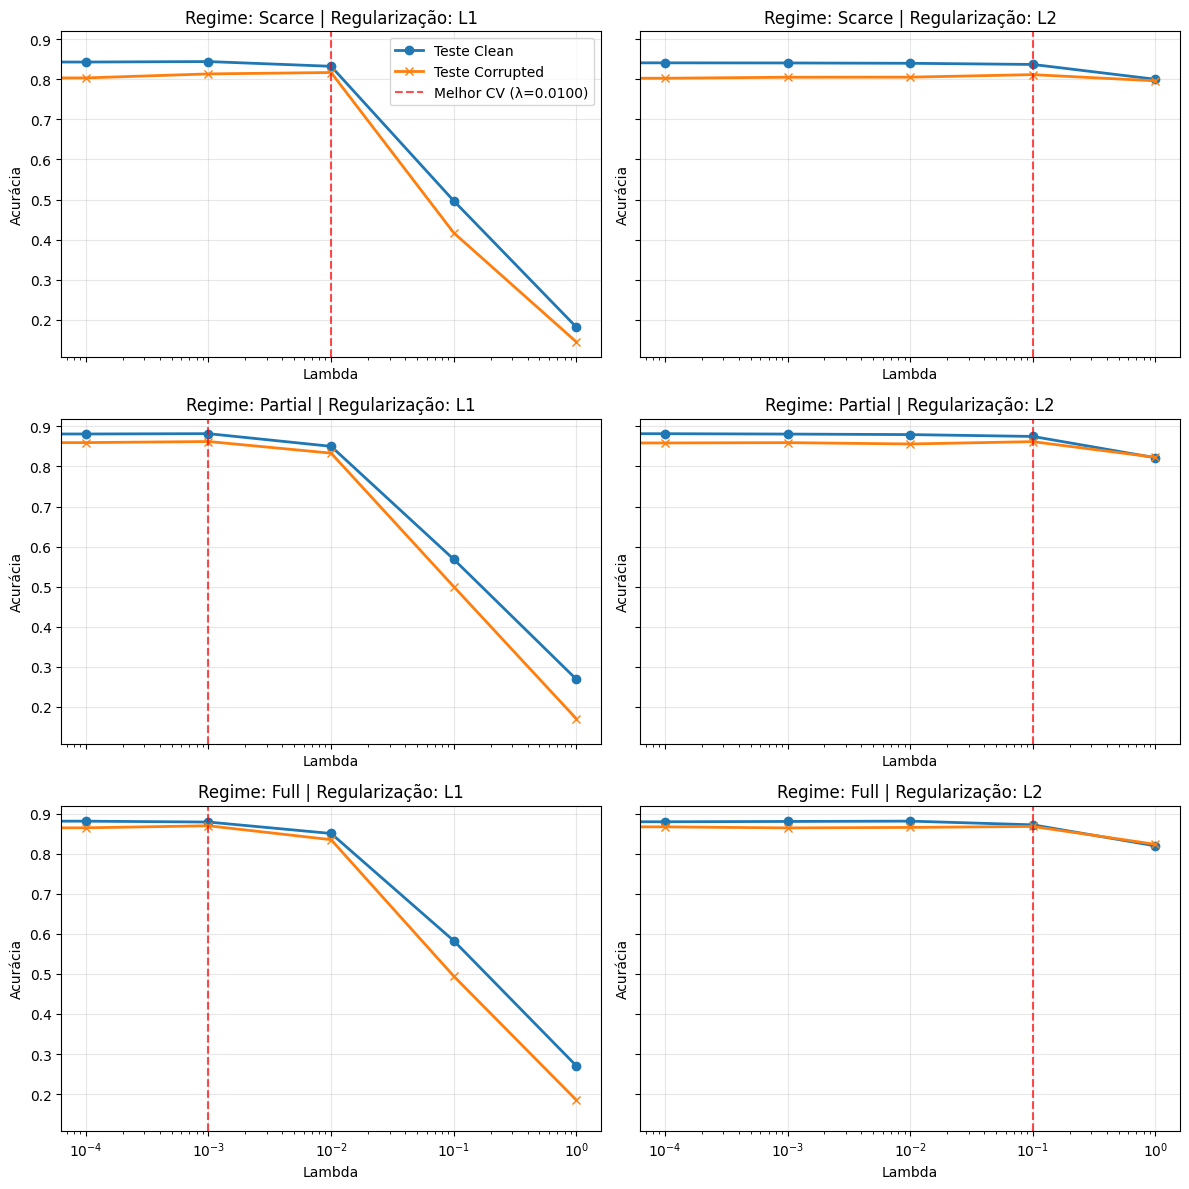

In [27]:
import matplotlib.pyplot as plt

# Definindo a ordem das linhas e colunas para o grid
regimes = list(data_regimes.keys()) # Ex: ["full", "parcial", "scarce"]
reg_types = ["L1", "L2"]

# Criando a figura e a grade de subplots (3 linhas, 2 colunas)
# sharey=True ajuda a comparar a acurácia na mesma escala em todos os gráficos
fig, axes = plt.subplots(nrows=len(regimes), ncols=len(reg_types), 
                         figsize=(12, 12), sharex=True, sharey=True)

for i, regime in enumerate(regimes):
    for j, reg_type in enumerate(reg_types):
        ax = axes[i, j]
        
        # Filtrando o DataFrame para o subplot atual
        mask = (df['Regime'] == regime) & (df['Type'] == reg_type)
        subset = df[mask].sort_values('Lambda')
        
        # Plotando as linhas de Teste (Clean e Corrupted)
        ax.plot(subset['Lambda'], subset['Clean_Acc'], 
                label='Teste Clean', marker='o', color='#1f77b4', linewidth=2)
        ax.plot(subset['Lambda'], subset['Corr_Acc'], 
                label='Teste Corrupted', marker='x', color='#ff7f0e', linewidth=2)
        
        # Destacando o melhor lambda escolhido pelo CV
        best_cv_row = subset[subset['Is_Best_CV'] == True]
        if not best_cv_row.empty:
            best_lam = best_cv_row['Lambda'].values[0]
            ax.axvline(x=best_lam, color='red', linestyle='--', alpha=0.7, 
                       label=f'Melhor CV (λ={best_lam:.4f})')
        
        # Formatando o eixo X para escala logarítmica
        ax.set_xscale('log')
        
        # Títulos e labels
        ax.set_title(f'Regime: {regime} | Regularização: {reg_type}')
        ax.set_xlabel('Lambda')
        ax.set_ylabel('Acurácia')
        ax.grid(True, alpha=0.3)
        
        # Adicionando a legenda apenas no primeiro gráfico para não poluir
        if i == 0 and j == 0:
            ax.legend()

# Ajusta o espaçamento para que os títulos não fiquem sobrepostos
plt.tight_layout()
plt.show()

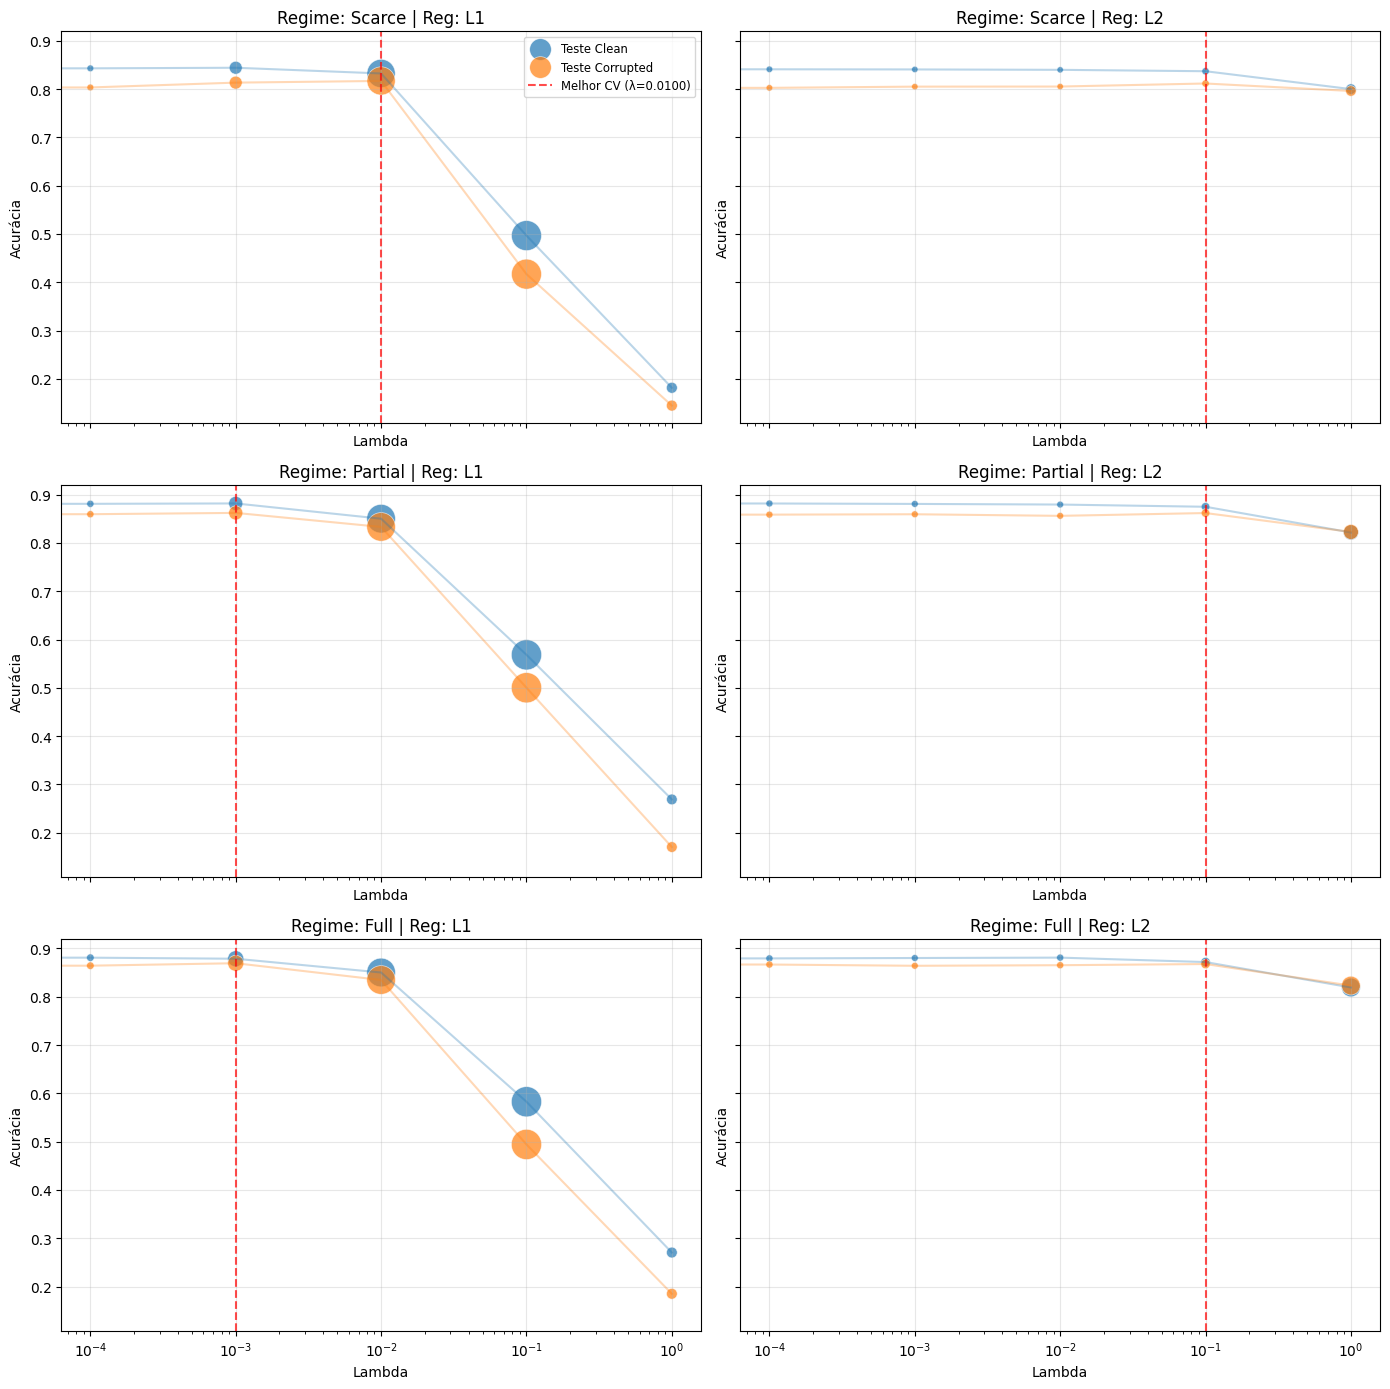

In [28]:
fig, axes = plt.subplots(nrows=len(regimes), ncols=len(reg_types),
                         figsize=(14, 14), sharex=True, sharey=True)

for i, regime in enumerate(regimes):
    for j, reg_type in enumerate(reg_types):
        ax = axes[i, j]
        # Filtrando o DataFrame para o subplot atual
        mask = (df['Regime'] == regime) & (df['Type'] == reg_type)
        subset = df[mask].sort_values('Lambda')

        # Multiplicador para o tamanho do ponto ficar visível
        # Usamos s=(esparsidade * 500) + 10 para garantir um tamanho mínimo
        sizes = (subset['Sparsity'] * 500) + 10

        # Plotando Clean Acc (Tamanho do ponto = Esparsidade)
        scatter_clean = ax.scatter(subset['Lambda'], subset['Clean_Acc'],
                                   s=sizes, c='#1f77b4', alpha=0.7,
                                   edgecolors='white', linewidth=0.5,
                                   label='Teste Clean')

        # Plotando Corr Acc (Tamanho do ponto = Esparsidade)
        scatter_corr = ax.scatter(subset['Lambda'], subset['Corr_Acc'],
                                  s=sizes, c='#ff7f0e', alpha=0.7,
                                  edgecolors='white', linewidth=0.5,
                                  label='Teste Corrupted')

        # Adicionando uma linha suave para conectar os pontos e mostrar a tendência
        ax.plot(subset['Lambda'], subset['Clean_Acc'], c='#1f77b4', alpha=0.3, linestyle='-')
        ax.plot(subset['Lambda'], subset['Corr_Acc'], c='#ff7f0e', alpha=0.3, linestyle='-')

        # Destacando o melhor lambda
        best_cv_row = subset[subset['Is_Best_CV'] == True]
        if not best_cv_row.empty:
            best_lam = best_cv_row['Lambda'].values[0]
            ax.axvline(x=best_lam, color='red', linestyle='--', alpha=0.7,
                       label=f'Melhor CV (λ={best_lam:.4f})')

        ax.set_xscale('log')
        ax.set_title(f'Regime: {regime} | Reg: {reg_type}')
        ax.set_xlabel('Lambda')
        ax.set_ylabel('Acurácia')
        ax.grid(True, alpha=0.3)

        # Adicionando legenda no primeiro gráfico
        if i == 0 and j == 0:
            # Para a legenda de tamanho (esparsidade), criamos pontos artificiais
            handles, labels = ax.get_legend_handles_labels()
            # Criar um scatter vazio apenas para a legenda de tamanho
            # l1 = plt.scatter([],[], s=(0.1 * 500) + 10, color='gray', alpha=0.5, edgecolors='white', label='10% Esparso')
            # l2 = plt.scatter([],[], s=(0.5 * 500) + 10, color='gray', alpha=0.5, edgecolors='white', label='50% Esparso')
            # l3 = plt.scatter([],[], s=(0.9 * 500) + 10, color='gray', alpha=0.5, edgecolors='white', label='90% Esparso')
            # handles.extend([l1, l2, l3])
            ax.legend(handles=handles, loc='best', fontsize='small')

plt.tight_layout()
plt.show()

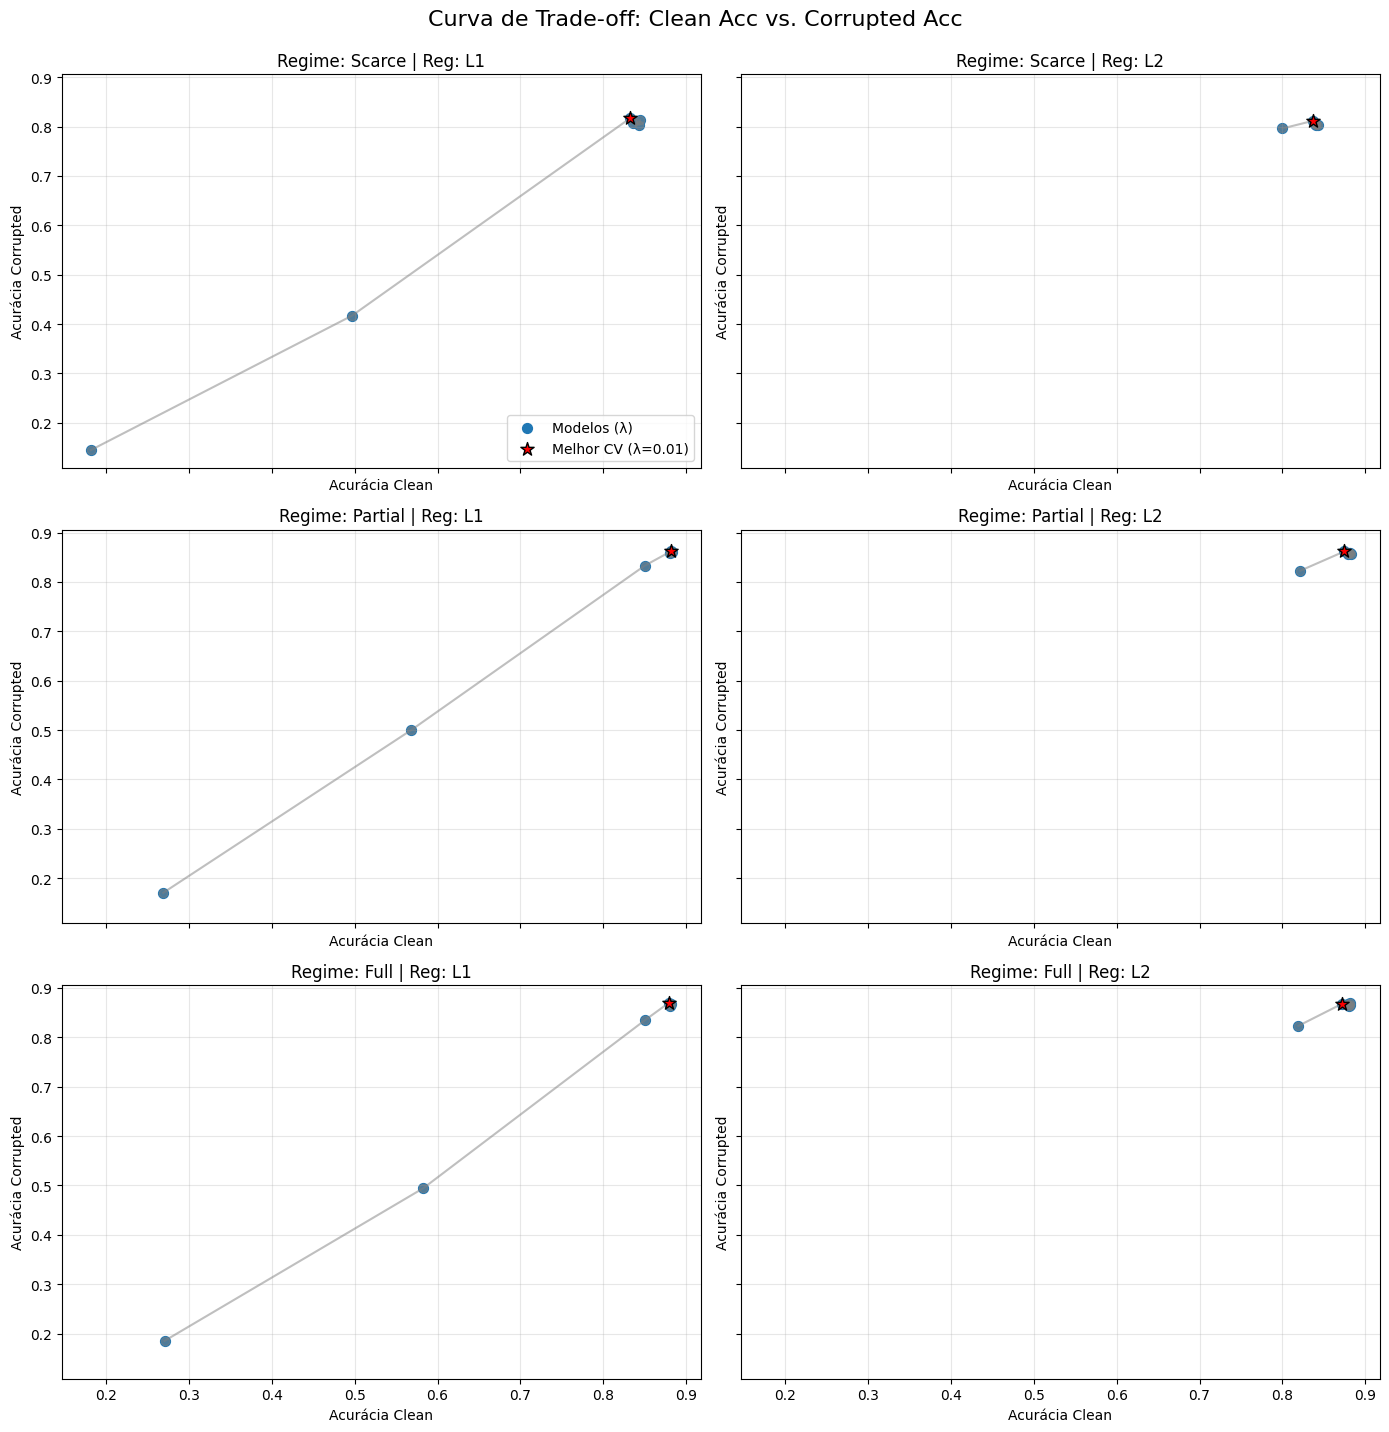

In [29]:
import matplotlib.pyplot as plt

# Criando a figura para os plots de trade-off
fig, axes = plt.subplots(nrows=len(regimes), ncols=len(reg_types), 
                         figsize=(14, 14), sharex=True, sharey=True)

for i, regime in enumerate(regimes):
    for j, reg_type in enumerate(reg_types):
        ax = axes[i, j]
        
        # Filtra os dados
        mask = (df['Regime'] == regime) & (df['Type'] == reg_type)
        subset = df[mask].sort_values('Lambda')
        
        # Plota a curva (cada ponto é um lambda)
        ax.plot(subset['Clean_Acc'], subset['Corr_Acc'], 
                marker='o', color='gray', linestyle='-', alpha=0.5)
        
        ax.scatter(subset['Clean_Acc'], subset['Corr_Acc'], 
                   color='#1f77b4', s=50, label='Modelos (\u03bb)')
        
        # Destaca o modelo escolhido pelo CV
        best_cv_row = subset[subset['Is_Best_CV'] == True]
        if not best_cv_row.empty:
            ax.scatter(best_cv_row['Clean_Acc'], best_cv_row['Corr_Acc'], 
                       color='red', s=100, marker='*', edgecolor='black', zorder=5,
                       label=f'Melhor CV (\u03bb={best_cv_row["Lambda"].values[0]})')
        
        # Textos e formatação
        ax.set_title(f'Regime: {regime} | Reg: {reg_type}')
        ax.set_xlabel('Acurácia Clean')
        ax.set_ylabel('Acurácia Corrupted')
        ax.grid(True, alpha=0.3)
        
        if i == 0 and j == 0:
            ax.legend(loc='lower right')

plt.tight_layout()
plt.suptitle('Curva de Trade-off: Clean Acc vs. Corrupted Acc', y=1.02, fontsize=16)
plt.show()


In [30]:
baseline_df = df[df['Lambda'] == 0.0].drop_duplicates(subset=['Regime'])
display(baseline_df[['Regime', 'Lambda', 'Clean_Acc', 'Corr_Acc']])


,Regime,Lambda,Clean_Acc,Corr_Acc
0,Scarce,0.0,0.8357,0.8068
12,Partial,0.0,0.8827,0.8611
24,Full,0.0,0.8813,0.8675


In [31]:
sparsity_table = df[["Regime", "Type", "Lambda", "Sparsity", "Is_Best_CV"]].copy()
sparsity_table = sparsity_table.sort_values(["Regime", "Type", "Lambda"]).reset_index(drop=True)

# Create a pivot table for better visualization
pivot_sparsity = sparsity_table.pivot_table(
    index=["Regime", "Type"],
    columns="Lambda",
    values="Sparsity",
    aggfunc="first"
)

print("=" * 100)
print("SPARSITY TABLE - All Models")
print("=" * 100)
print(pivot_sparsity.to_string())
print()

# Highlight best CV models
print("=" * 100)
print("BEST CV MODELS - Sparsity Values")
print("=" * 100)
best_cv_table = sparsity_table[sparsity_table["Is_Best_CV"] == True][
    ["Regime", "Type", "Lambda", "Sparsity"]
].reset_index(drop=True)
print(best_cv_table.to_string(index=False))
print()

# Create a detailed table with all metrics for best CV
print("=" * 100)
print("BEST CV MODELS - Full Details")
print("=" * 100)
best_cv_details = df[df["Is_Best_CV"] == True][
    ["Regime", "Type", "Lambda", "Clean_Acc", "Corr_Acc", "Sparsity"]
].reset_index(drop=True)
print(best_cv_details.to_string(index=False))

baseline_df = df[df['Lambda'] == 0.0].drop_duplicates(subset=['Regime'])
display(baseline_df[['Regime', 'Lambda', 'Clean_Acc', 'Corr_Acc']])


SPARSITY TABLE - All Models
Lambda          0.0000    0.0001    0.0010    0.0100    0.1000    1.0000
Regime  Type                                                            
Full    L1    0.032398  0.038648  0.245791  0.832526  0.927296  0.100383
        L2    0.032143  0.032015  0.028699  0.032015  0.070536  0.344515
Partial L1    0.027296  0.032908  0.185459  0.829464  0.929974  0.097832
        L2    0.026020  0.029974  0.028571  0.027806  0.054719  0.213265
Scarce  L1    0.021301  0.027423  0.151913  0.806505  0.913265  0.103444
        L2    0.020918  0.024107  0.021939  0.021301  0.035459  0.094515

BEST CV MODELS - Sparsity Values
 Regime Type  Lambda  Sparsity
   Full   L1   0.001  0.245791
   Full   L2   0.100  0.070536
Partial   L1   0.001  0.185459
Partial   L2   0.100  0.054719
 Scarce   L1   0.010  0.806505
 Scarce   L2   0.100  0.035459

BEST CV MODELS - Full Details
 Regime Type  Lambda  Clean_Acc  Corr_Acc  Sparsity
 Scarce   L1   0.010     0.8324    0.8169  0.806505
 S

,Regime,Lambda,Clean_Acc,Corr_Acc
0,Scarce,0.0,0.8357,0.8068
12,Partial,0.0,0.8827,0.8611
24,Full,0.0,0.8813,0.8675


In [39]:
import pandas as pd

comparacao = []

for regime in df['Regime'].unique():
    for reg_type in df['Type'].unique():
        subset = df[(df['Regime'] == regime) & (df['Type'] == reg_type)]
        
        # Dados do modelo CV
        cv_model = subset[subset['Is_Best_CV'] == True].iloc[0]
        lambda_cv = cv_model['Lambda']
        clean_cv = cv_model['Clean_Acc']
        corr_cv = cv_model['Corr_Acc']
        
        # Dados do modelo com a MELHOR Acurácia no Teste Clean (Out-of-Distribution)
        best_clean_model = subset.loc[subset['Clean_Acc'].idxmax()]
        lambda_best = best_clean_model['Lambda']
        clean_best = best_clean_model['Clean_Acc']
        corr_best = best_clean_model['Corr_Acc']

        
        comparacao.append({
            'Regime': regime,
            'Tipo': reg_type,
            'Lambda(CV)': lambda_cv,
            'Clean(CV)': round(clean_cv, 4),
            'Corr(CV)': round(corr_cv, 4),
            '|': '|',
            'Lambda(Melhor OOD)': lambda_best,
            'Clean(Melhor OOD)': round(clean_best, 4),
            'Corr(Melhor OOD)': round(corr_best, 4)
        })

df_comp2 = pd.DataFrame(comparacao)
display(df_comp2)


,Regime,Tipo,Lambda(CV),Clean(CV),Corr(CV),|,Lambda(Melhor OOD),Clean(Melhor OOD),Corr(Melhor OOD)
0,Scarce,L1,0.010,0.8324,0.8169,|,0.001,0.8442,0.8134
1,Scarce,L2,0.100,0.8370,0.8116,|,0.000,0.8435,0.8030
2,Partial,L1,0.001,0.8818,0.8622,|,0.000,0.8827,0.8611
3,Partial,L2,0.100,0.8749,0.8619,|,0.000,0.8825,0.8568
4,Full,L1,0.001,0.8788,0.8695,|,0.000,0.8813,0.8675
5,Full,L2,0.100,0.8719,0.8678,|,0.010,0.8811,0.8654


In [34]:

# Opção 2: Tabela em formato Pivot (L1 e L2 lado a lado)
# Facilita muito comparar como a acurácia mudou entre Lasso e Ridge
tabela_pivo = df.pivot_table(
    index=['Regime', 'Lambda'], 
    columns='Type', 
    values=['Clean_Acc', 'Corr_Acc']
)

print("\n--- Comparação L1 vs L2 Lado a Lado ---")
display(tabela_pivo)



--- Comparação L1 vs L2 Lado a Lado ---


Clean_Acc         Corr_Acc        
Type                  L1      L2       L1      L2
Regime  Lambda                                   
Full    0.0000    0.8813  0.8810   0.8675  0.8689
        0.0001    0.8810  0.8795   0.8644  0.8668
        0.0010    0.8788  0.8803   0.8695  0.8642
        0.0100    0.8503  0.8811   0.8348  0.8654
        0.1000    0.5827  0.8719   0.4943  0.8678
        1.0000    0.2705  0.8193   0.1851  0.8232
Partial 0.0000    0.8827  0.8825   0.8611  0.8568
        0.0001    0.8810  0.8817   0.8595  0.8586
        0.0010    0.8818  0.8808   0.8622  0.8594
        0.0100    0.8502  0.8795   0.8332  0.8561
        0.1000    0.5684  0.8749   0.5002  0.8619
        1.0000    0.2690  0.8217   0.1704  0.8228
Scarce  0.0000    0.8357  0.8435   0.8068  0.8030
        0.0001    0.8430  0.8410   0.8034  0.8026
        0.0010    0.8442  0.8407   0.8134  0.8051
        0.0100    0.8324  0.8399   0.8169  0.8053
        0.1000    0.4967  0.8370   0.4169  0.8116
        1.0000    0.1816  0.8000   0.1447  0.7961

In [33]:
df_partial_l2 = df[(df['Regime'] == 'Partial') & (df['Type'] == 'L2')]
display(df_partial_l2[['Lambda', 'Clean_Acc', 'Corr_Acc', 'Is_Best_CV']])


,Lambda,Clean_Acc,Corr_Acc,Is_Best_CV
18,0.0000,0.8825,0.8568,False
19,0.0001,0.8817,0.8586,False
20,0.0010,0.8808,0.8594,False
21,0.0100,0.8795,0.8561,False
22,0.1000,0.8749,0.8619,True
23,1.0000,0.8217,0.8228,False


In [38]:
# 1. Calcula o Gap (Corrupted - Clean) e o Gap Absoluto
df['Gap'] = df['Corr_Acc'] - df['Clean_Acc']
df['Abs_Gap'] = df['Gap'].abs()

# 2. Cria uma tabela focada no Gap, ordenada por Regime, Tipo e Lambda
df_gap = df[['Regime', 'Type', 'Lambda', 'Clean_Acc', 'Corr_Acc', 'Gap', 'Abs_Gap']].copy()
df_gap = df_gap.sort_values(by=['Regime', 'Type', 'Lambda']).reset_index(drop=True)

print("--- Tabela Completa com os In/Out Gaps ---")
display(df_gap)

# 3. Tabela Dinâmica (Pivot) para comparar o Gap do L1 e L2 lado a lado
tabela_pivo_gap = df.pivot_table(
    index=['Regime', 'Lambda'], 
    columns='Type', 
    values='Gap'
)

print("\n--- Comparação do Gap (L1 vs L2) Lado a Lado ---")
display(tabela_pivo_gap)

# 4. Encontra automaticamente os menores Gaps Absolutos para o seu Summary
print("\n--- Vencedores: Modelos com o Menor In/Out Gap Absoluto ---")
# Filtra os índices com os menores gaps para L1 e L2
idx_menor_l1 = df[df['Type'] == 'L1']['Abs_Gap'].idxmin()
idx_menor_l2 = df[df['Type'] == 'L2']['Abs_Gap'].idxmin()

display(df.loc[[idx_menor_l1, idx_menor_l2], 
               ['Regime', 'Type', 'Lambda', 'Clean_Acc', 'Corr_Acc', 'Gap']])


--- Tabela Completa com os In/Out Gaps ---


,Regime,Type,Lambda,Clean_Acc,Corr_Acc,Gap,Abs_Gap
0,Full,L1,0.0000,0.8813,0.8675,-0.0138,0.0138
1,Full,L1,0.0001,0.8810,0.8644,-0.0166,0.0166
2,Full,L1,0.0010,0.8788,0.8695,-0.0093,0.0093
3,Full,L1,0.0100,0.8503,0.8348,-0.0155,0.0155
4,Full,L1,0.1000,0.5827,0.4943,-0.0884,0.0884
5,Full,L1,1.0000,0.2705,0.1851,-0.0854,0.0854
6,Full,L2,0.0000,0.8810,0.8689,-0.0121,0.0121
7,Full,L2,0.0001,0.8795,0.8668,-0.0127,0.0127
8,Full,L2,0.0010,0.8803,0.8642,-0.0161,0.0161
9,Full,L2,0.0100,0.8811,0.8654,-0.0157,0.0157



--- Comparação do Gap (L1 vs L2) Lado a Lado ---


Type                L1      L2
Regime  Lambda                
Full    0.0000 -0.0138 -0.0121
        0.0001 -0.0166 -0.0127
        0.0010 -0.0093 -0.0161
        0.0100 -0.0155 -0.0157
        0.1000 -0.0884 -0.0041
        1.0000 -0.0854  0.0039
Partial 0.0000 -0.0216 -0.0257
        0.0001 -0.0215 -0.0231
        0.0010 -0.0196 -0.0214
        0.0100 -0.0170 -0.0234
        0.1000 -0.0682 -0.0130
        1.0000 -0.0986  0.0011
Scarce  0.0000 -0.0289 -0.0405
        0.0001 -0.0396 -0.0384
        0.0010 -0.0308 -0.0356
        0.0100 -0.0155 -0.0346
        0.1000 -0.0798 -0.0254
        1.0000 -0.0369 -0.0039


--- Vencedores: Modelos com o Menor In/Out Gap Absoluto ---


,Regime,Type,Lambda,Clean_Acc,Corr_Acc,Gap
26,Full,L1,0.001,0.8788,0.8695,-0.0093
23,Partial,L2,1.000,0.8217,0.8228,0.0011


In [46]:
df_l2_lambda1 = df[(df['Type'] == 'L2') & (df['Lambda'] == 1.0)]
display(df_l2_lambda1[['Regime', 'Lambda', 'Clean_Acc', 'Corr_Acc']])


,Regime,Lambda,Clean_Acc,Corr_Acc
11,Scarce,1.0,0.8000,0.7961
23,Partial,1.0,0.8217,0.8228
35,Full,1.0,0.8193,0.8232


> **Question 5**
>
> (a) Describe the shape of the trade-off curve (corrupted-test vs. clean-test). Is there a region where increasing regularization simultaneously improves both accuracies? Is there a region of genuine trade-off?
>
> (b) The CV-selected models are marked on the plot. Where do they fall relative to the trade-off frontier? What does this tell you about using cross-validation as a model selection criterion when training and deployment distributions differ?
>
> (c) Revisit your prediction from Question 4(d). Was it correct? If not, what did the weight images fail to reveal that the test results exposed?
>
> (d) Connect the sparsity plot to the OOD results. Why might L1 regularization behave differently from L2 when evaluated on clean images?
>
> (e) In a real deployment scenario, the clean test set would not be available during model selection. Given only corrupted validation data, what practical strategies could a practitioner use to make a better model selection decision than simply maximizing CV accuracy?


(a) Analisando as curvas plotadas, percebe-se que as diferenças nas acurácias entre as curvas não possui uma diferença significativa. Observando os gráficos, as tendências das duas curvas seguem comportamente similares, não demonstrando haver uma região de trade-off genuína. Por exemplo, no regime full com Regularização Lasso, na faixa entre $10^{-4}$ e $10^{-3}$ é perceptível uma melhora mínima no teste corrompido, enquanto há uma pequena queda na acurácia do teste clean, mas essa diferença é ínfima, o que não indica um trade-off real, ou seja, um cenário em que o aumento da regularização melhora significativamente a acurácia no teste corrompido, mas prejudica significativamente a acurácia no teste clean. Em geral, as curvas de acurácia para ambos os testes seguem uma tendência similar, indicando que as melhorias ou quedas na acurácia devido à regularização afetam ambos os testes de maneira semelhante, sem evidências claras de um trade-off genuíno ou sem regiões em que o aumento da regularização melhore significativamente as acurácias de ambos os testes simultaneamente.

(b) Observando os resultados obtidos, os modelos selecionados por CV caem próximos ao ponto ideal da fronteira, com diferenças numéricas quase irrelevantes em relação aos modelos absolutos de melhor desempenho. O fato de o CV ter escolhido um $\lambda$ que nem sempre é o pico absoluto do Clean provavelmente se deve à variância entre os conjuntos de validação e de teste. Notamos, também, que em 5 dos 6 modelos, a acurácia nos dados corrompidos é a maior. 

Entretanto, sabemos que os modelos treinados no processo de CV usam os dados de treino e selecionamos os melhores $\lambda$ para cada regime (sem ver os dados corrompidos, pois não queremos que haja vazamento do teste no treino). Por causa disso, não podemos afirmar que sempre será garantido que o melhor $\lambda$ escolhido na etapa de validação vai corresponder ao modelo de melhor acurácia no teste em distribuições diferentes. 

Logo, como a mudança para os dados corrompidos não alterou significativamente as tendências das curvas, o CV conseguiu selecionar hiperparâmetros competentes no teste. Porém, caso a distribuição fosse muito diferente e exigisse um nível de regularização distinto, a Validação Cruzada poderia falhar, pois continuaria selecionando o hiperparâmetro que maximiza a distribuição de treino, ignorando o cenário de implantação.

(c) Diferenças entre os tipos de regularização para o melhor lambda foram pequenas. A previsão era que o L1 performasse melhor no regime _scarce_ e o L2 melhor no _full_ e no _partial_. O que aconteceu foi que no dados clean, o L2 teve uma acurácia de $0.8370$ e o L1 de $0.8324$, o que foi o contrário do que previmos, porém a diferença é muito pequena. Já no regime _full_ e _partial_, o L1 teve as melhores acurácias nos dados limpos, com acurácias de $0.8818$ e $0.8788$ versus acurácias de $0.8749$ e $0.8719$ do regime L2, também contrastando com o que previmos na 4(d). 

Apesar do resultado ter sido o contrário do que previmos, essas diferenças foram estatisticamente pequenas. As imagens dos pesos da Questão 4 e os gráficos plotados que mostraram a L1 gerou representações mais limpas e esparsas, enquanto a L2 tinha pesos mais densos no fundo das imagens. Essa clareza visual do L1 nos induziu a pensar que o modelo teria uma superioridade preditiva  maior no _scarce_. No entanto, os resultados dos testes expuseram que clareza interpretável não refletiu, necessariamente, um desempenho superior. O ruído mantido pelo L2 também contém sinais preditivos fracos suficientes para empatar com a eficiência esparsa do L1, evidenciando que ambas as estratégias foram similares na prática.

Por fim, a leve superioridade do L1 nos regimes com mais dados sugere que, como a natureza das imagens de dígitos é esparsa (focada no centro), a indução de esparsidade do L1 consegue isolar  os pixels essenciais quando há abundância de dados, enquanto o L2 mantém pequenas interferências do ruído de fundo.

(d) No caso da regularização L1, é perceptível o aumento da esparsidade a medida que aumentamos o valor da regularização, o que faz sentido, dado que a Lasso pode zerar pesos, realizando feature selection. A L2, contudo, mantém o modelo denso, distribuindo os pesos por praticamente todos os pixels da imagem. A regularização L1, quando avaliada em imagens sem ruído, pode se comportar diferentemente da L2, pois a sua predição pode depender de um subconjunto de pixels menor e mais essenciais para a classificação (devido ao processo de feature selection, o que leva a sua maior esparsidade). Como a regularização Ridge não faz isso, ela pode acabar memorizando ruídos, o que pode levar ao overfitting e baixo poder de generalização OOD. Cabe mencionar, por fim, que para valores altos de $\lambda$, a Lasso pode zerar features importantes, aumentando o viés do modelo e diminuindo a sua acurácia, como podemos perceber nos gráficos para os três regimes de dados. Isso não ocorre na L2, que se mantém mais estável mesmo com $\lambda$ maiores.

(e) Caso não tivéssemos os dados limpos para realizar a seleção do modelo, se apenas nos baseassemos em maximizar a acurácia do CV provavelmente haveria risco do modelo decorar ruídos e levar ao overfitting. Possíveis formas de contornar isso poderiam ser fazendo uma análise mais detalhada da importância de features, como por exemplo analisando a matriz de pesos para diferentes valores de hiperparâmetros. Uma outra forma seria priorizar modelos mais esparsos (mas de modo que não leve ao underfitting), mais simples.

---

## Summary

Complete the table below with results from your experiments. Use the best model according to each criterion.

| Model                              | CV Accuracy | Test Acc (corrupted) | Test Acc (clean) | Gap  |
|------------------------------------|-------------|----------------------|------------------|------|
| No regularization (baseline)       |     -        |           0.8675           |           0.8827       |   -0.0152   |
| Best CV, L2                        |     0.8574        |           0.8678           |         0.8749         |   -0.0071   |
| Best CV, L1                        |     0.8593        |           0.8695           |         0.8818         |   -0.0123   |
| Smallest in/out gap, L2            |     0.8084        |         0.8228             |        0.8217          |   0.0011   |
| Smallest in/out gap, L1            |     0.8593        |           0.8695           |        0.8788          |   -0.0093   |

*Gap = Test Acc (corrupted) - Test Acc (clean).*

---

## Assignment Submission

This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.

Before submitting, verify that:
- The notebook runs end-to-end without errors (use **Run All** after restarting the kernel).
- All plots are rendered in the output.
- All written answers are filled in.
- The summary table is completed.
- AI usage declaration and prompts are included if applicable.

**Important: Only one member of the group should submit.**

### Policy for late submissions

You are NOT encouraged to submit after the deadline; however, in this case the following penalties apply:

- 25% deduction for 1-day late submission.
- 50% deduction for 2-day late submission.
- 75% deduction for 3-day late submission.